In [126]:
%load_ext autoreload

In [208]:
%autoreload 2
%aimport sog1_helpers
import pandas as pd
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

from scipy.stats import pearsonr

# Ignore all warnings
warnings.filterwarnings('ignore')

# What are the differences between Jordan and Emily's scores?

## 1. Loading in scores and merging

In [86]:
js_activities = pd.read_csv("../data/Sog1_library2_activities_with_reads.csv")
ec_activities = pd.read_csv("../data/Sog1_library2_activities_with_reads_ECspike.csv")
#activities = pd.read_csv("../data/Sog1_library2_activities_with_reads_EC.csv")

In [87]:
js_activities

,ArrayDNA,Activity_GFP8,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,636.156202,614.613867,944.856101,6448.0,115.0,EDPTWFDSGSQFILNSQQLVEALSLCDDAAGSQDREENTN,779.734984,233.516523
1,GAAGCTTTGTCTTTGTGTGATGATTTGTTGGGTGATCAAGATAGAG...,602.696194,541.936177,992.565641,10829.0,1680.0,EALSLCDDLLGDQDREENDNDGDLKDKQPCIADYAHLGPE,767.250909,318.643150
2,GATTTGGCTGAAGATGATGAAGTTATGTGTATGGAAGATGAAGTTC...,381.502348,390.255889,390.758385,91062.0,892.0,DLAEDDEVMCMEDEVQSIQPNHERPDDGPELEHGLENGAK,390.507137,0.355319
3,GGTCAAAGGAAGAGAAGGAAGATTACTCCAACTTTGGTTAATGATG...,347.155741,430.848450,865.176167,13900.0,140.0,GQRKRRKITPTLVNDEPVRWHKTGRTKPVMLSGVQRGCKK,648.012309,307.116074
4,TCTGAATTGACTTCTACTTTGGGTATTTCTCATAGATTGCCACAAT...,437.694050,470.823534,3562.821795,10128.0,246.0,SELTSTLGISHRLPQSLTPCVKTGSLQSGGLVQSVPFEEL,2016.822664,2186.372938
...,...,...,...,...,...,...,...,...,...
10304,TTGGAACATGGTTTGGAAAGAGGTGCTAAAGAAATGTTGGATGATA...,NaN,NaN,3570.989020,NaN,11.0,LEHGLERGAKEMLDDKEEREKDRDRERRGEEDPTWFDSGS,3570.989020,NaN
10305,GAAGATGAAGAATGGTTTGATGAAGAAGCTCAATTTATCTTGAATG...,NaN,NaN,3330.752810,NaN,13.0,EDEEWFDEEAQFILNAQQLVEALSLCDDLLGAQDREEEEN,3330.752810,NaN
10306,ACTCAATCTCAATCTTCTAGATCTAGAAATATTCCACCACCACAAG...,NaN,NaN,5347.917675,NaN,11.0,TQSQSSRSRNIPPPQANSSRAREIGNGSKTTMVDEIPMSV,5347.917675,NaN
10307,GACTTTAAGAGAGATTTGGAAGAATGTCAGAAGATTGTCTTGGATC...,NaN,NaN,5545.836977,NaN,21.0,DFKRDLEECQKIVLDPSNIELRPDPETFLSQLEFGSQDSF,5545.836977,NaN


In [88]:
ec_activities

,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1079.074274,925.703811,610.0,643.0,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,1002.389042,108.449295
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1394.076068,1424.548173,44354.0,36001.0,KQRDNEDNGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1409.312120,21.547032
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,1371.861742,1170.193129,68.0,38.0,KQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRM,1271.027436,142.601244
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.663233,267.611412,5090.0,7330.0,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,275.637323,11.350351
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,4076.691936,3163.539743,172.0,137.0,KQIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,3620.115839,645.696108
...,...,...,...,...,...,...,...,...
11264,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,2314.792506,2111.813429,124.0,121.0,FDSPDVAESFETSPLFANADADLAGQDAWFSLFPSISGGE,2213.302968,143.527882
11265,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,4433.599889,4873.732571,6379.0,8831.0,FDWEPTDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,4653.666230,311.220804
11266,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1673.484641,1569.322449,816.0,769.0,FAAGARKRRKIHDDDFGDVRWHKAGRAKPVVLDGVQRGCK,1621.403545,73.653793
11267,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1780.391373,2360.015854,75.0,73.0,FVKDSLQDIGKYFEIDSTLDELEQVESGEGNDDLPDEEER,2070.203613,409.856401


In [89]:
both = pd.merge(js_activities, ec_activities, on = "ArrayDNA", suffixes = ("_js", "_ec"))
both

,ArrayDNA,Activity_GFP8,Activity_S3_1_js,Activity_S3_2_js,reads_S3_1_js,reads_S3_2_js,AAseq_js,lib2_avg_js,lib2_std_js,Activity_S3_1_ec,Activity_S3_2_ec,reads_S3_1_ec,reads_S3_2_ec,AAseq_ec,lib2_avg_ec,lib2_std_ec
0,ATTATTTGGCATTTGTTGGCTAAATCTGGTTTGTCTGGTTTGTCTT...,451.955540,553.464718,495.706275,12342.0,3089.0,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,524.585497,40.841386,444.761592,369.638636,21291.0,27676.0,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,407.200114,53.119951
1,CCATCTGATTATGTTTCTGCTCATGAAGTTTCTTTGGCTGAAACTT...,423.885353,551.450656,764.304915,16211.0,1899.0,PSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPE,657.877786,150.510690,749.687642,716.012754,17170.0,20078.0,PSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPE,732.850198,23.811742
2,GATTCTCATATTGCTTCTGATTATGTTACTCCATCTGATTATGTTT...,546.055903,544.271657,748.858276,21461.0,1105.0,DSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQP,646.564966,144.664585,1205.673067,921.201730,80.0,88.0,DSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQP,1063.437398,201.151612
3,CAATTTATCTTAAATTCTCAACAATTGGTTGAAGCTTTGTCTTTGT...,504.125469,525.528897,922.926861,4034.0,86.0,QFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPC,724.227879,281.002795,1516.022615,1985.812713,34.0,33.0,QFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPC,1750.917664,332.191764
4,TCTTTGGCTGAAACTTCTGAAGTTATGTGTATGGAAGATGAAGTTC...,383.458535,489.352841,1398.678654,3555.0,178.0,SLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAK,944.015747,642.990448,3495.779407,3769.355633,228.0,189.0,SLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAK,3632.567520,193.447605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9245,TTGGAACATGGTTTGGAAAGAGGTGCTAAAGAAATGTTGGATGATA...,NaN,NaN,3570.989020,NaN,11.0,LEHGLERGAKEMLDDKEEREKDRDRERRGEEDPTWFDSGS,3570.989020,NaN,3740.123701,3447.077589,84.0,73.0,LEHGLERGAKEMLDDKEEREKDRDRERRGEEDPTWFDSGS,3593.600645,207.214893
9246,GAAGATGAAGAATGGTTTGATGAAGAAGCTCAATTTATCTTGAATG...,NaN,NaN,3330.752810,NaN,13.0,EDEEWFDEEAQFILNAQQLVEALSLCDDLLGAQDREEEEN,3330.752810,NaN,3638.512152,3078.099946,102.0,111.0,EDEEWFDEEAQFILNAQQLVEALSLCDDLLGAQDREEEEN,3358.306049,396.271271
9247,ACTCAATCTCAATCTTCTAGATCTAGAAATATTCCACCACCACAAG...,NaN,NaN,5347.917675,NaN,11.0,TQSQSSRSRNIPPPQANSSRAREIGNGSKTTMVDEIPMSV,5347.917675,NaN,2346.224267,1195.355529,12.0,18.0,TQSQSSRSRNIPPPQANSSRAREIGNGSKTTMVDEIPMSV,1770.789898,813.787089
9248,GACTTTAAGAGAGATTTGGAAGAATGTCAGAAGATTGTCTTGGATC...,NaN,NaN,5545.836977,NaN,21.0,DFKRDLEECQKIVLDPSNIELRPDPETFLSQLEFGSQDSF,5545.836977,NaN,3816.517233,3820.398149,56.0,72.0,DFKRDLEECQKIVLDPSNIELRPDPETFLSQLEFGSQDSF,3818.457691,2.744222


## 2. Comparing activity measurements

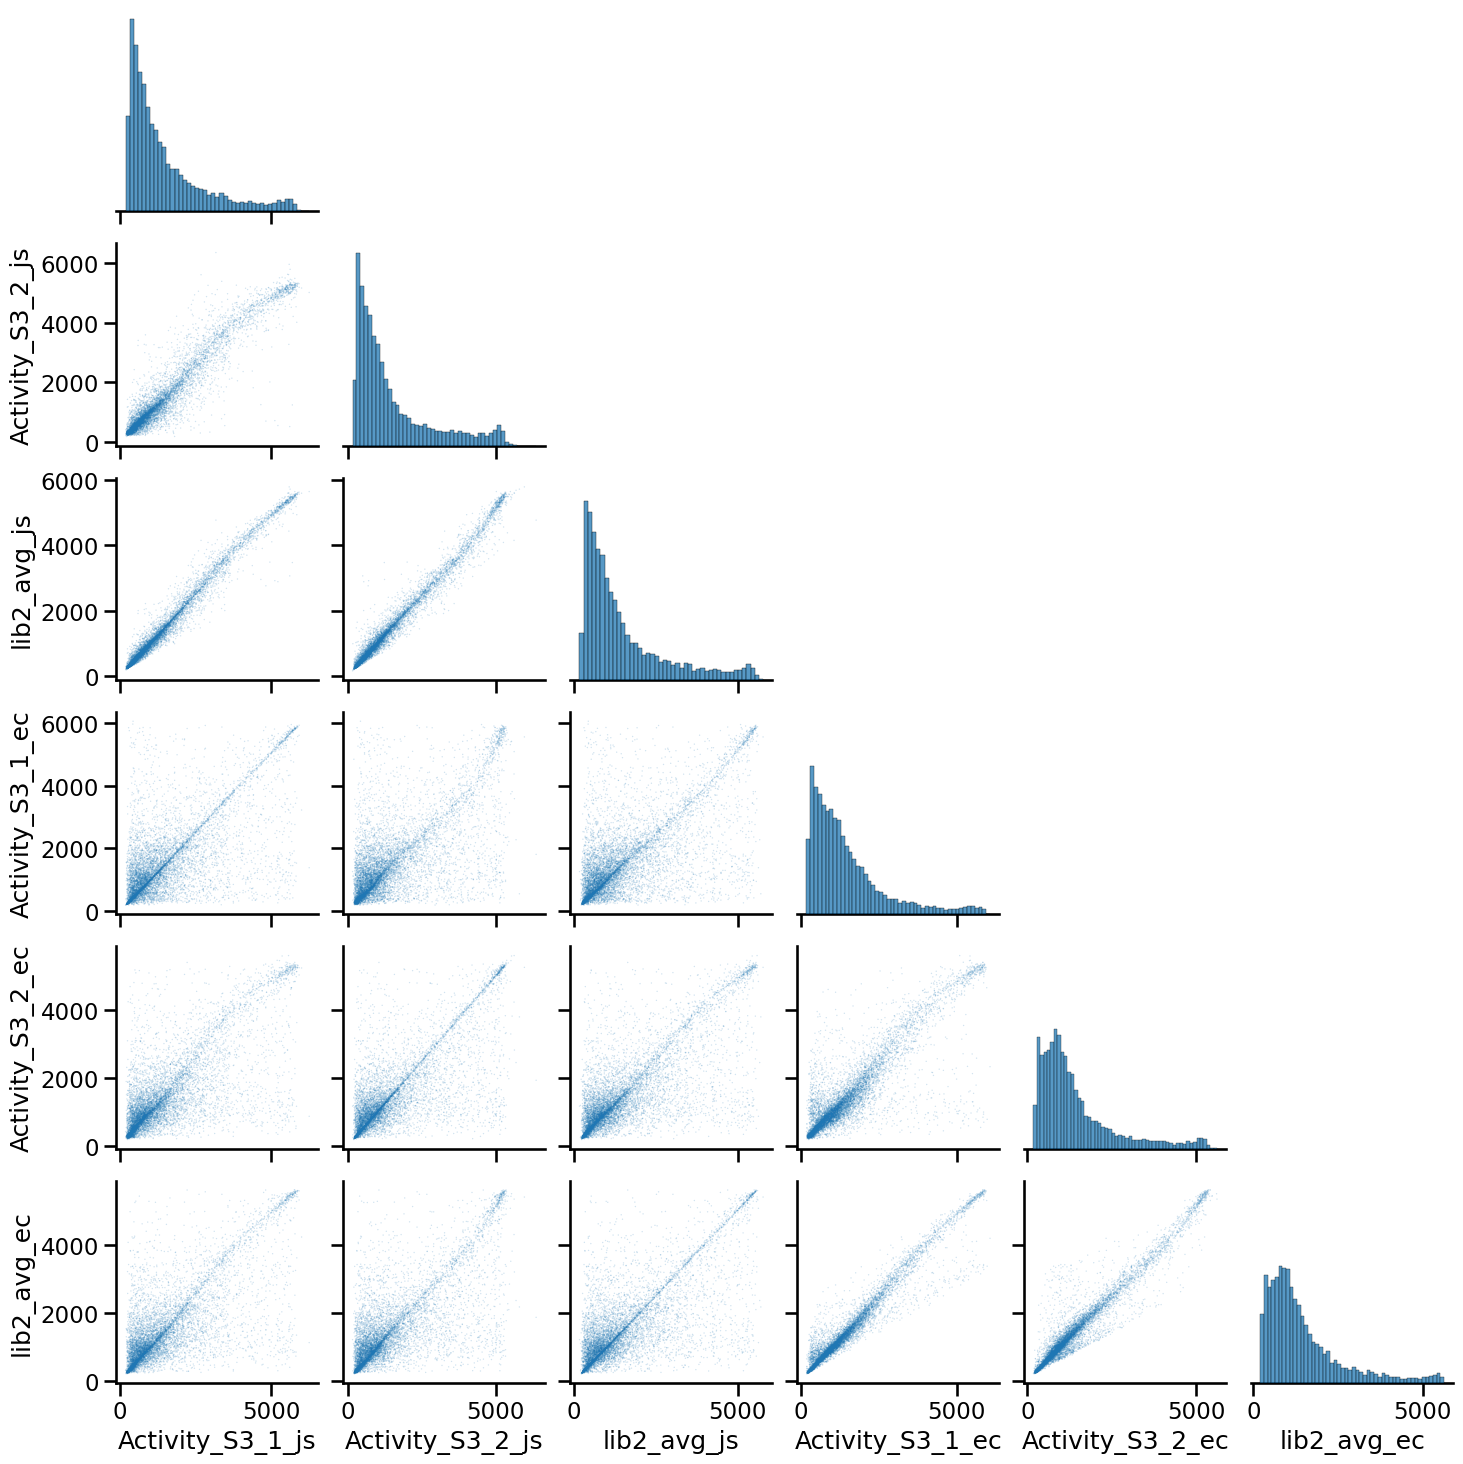

In [90]:
sns.set_context('talk')
sns.pairplot(both[["Activity_S3_1_js", "Activity_S3_2_js", "lib2_avg_js",
                   "Activity_S3_1_ec", "Activity_S3_2_ec", "lib2_avg_ec"]], 
             plot_kws = {'s' : 1, 'edgecolor' : 'none', 'alpha' : 0.2}, corner = True,)

In [160]:
def plot_correl(x, y, data = both, s = 4, alpha = 0.1, text_x = 6000, text_y = 300):
    sns.set_context('talk')
    df = data.dropna(subset = [x, y])
    sns.scatterplot(data = df, x = x, y = y, s = s, alpha = alpha, edgecolor = 'none')
    plt.text(x = text_x, y = text_y, 
             s = "Pearson\ncorrelation:\n" + str(pearsonr(x = df[x], y = df[y])[0])[:5],
            ha = "center", color = "red")
    sns.despine()

Text(0.5, 1.0, 'All Overlapping Tiles')

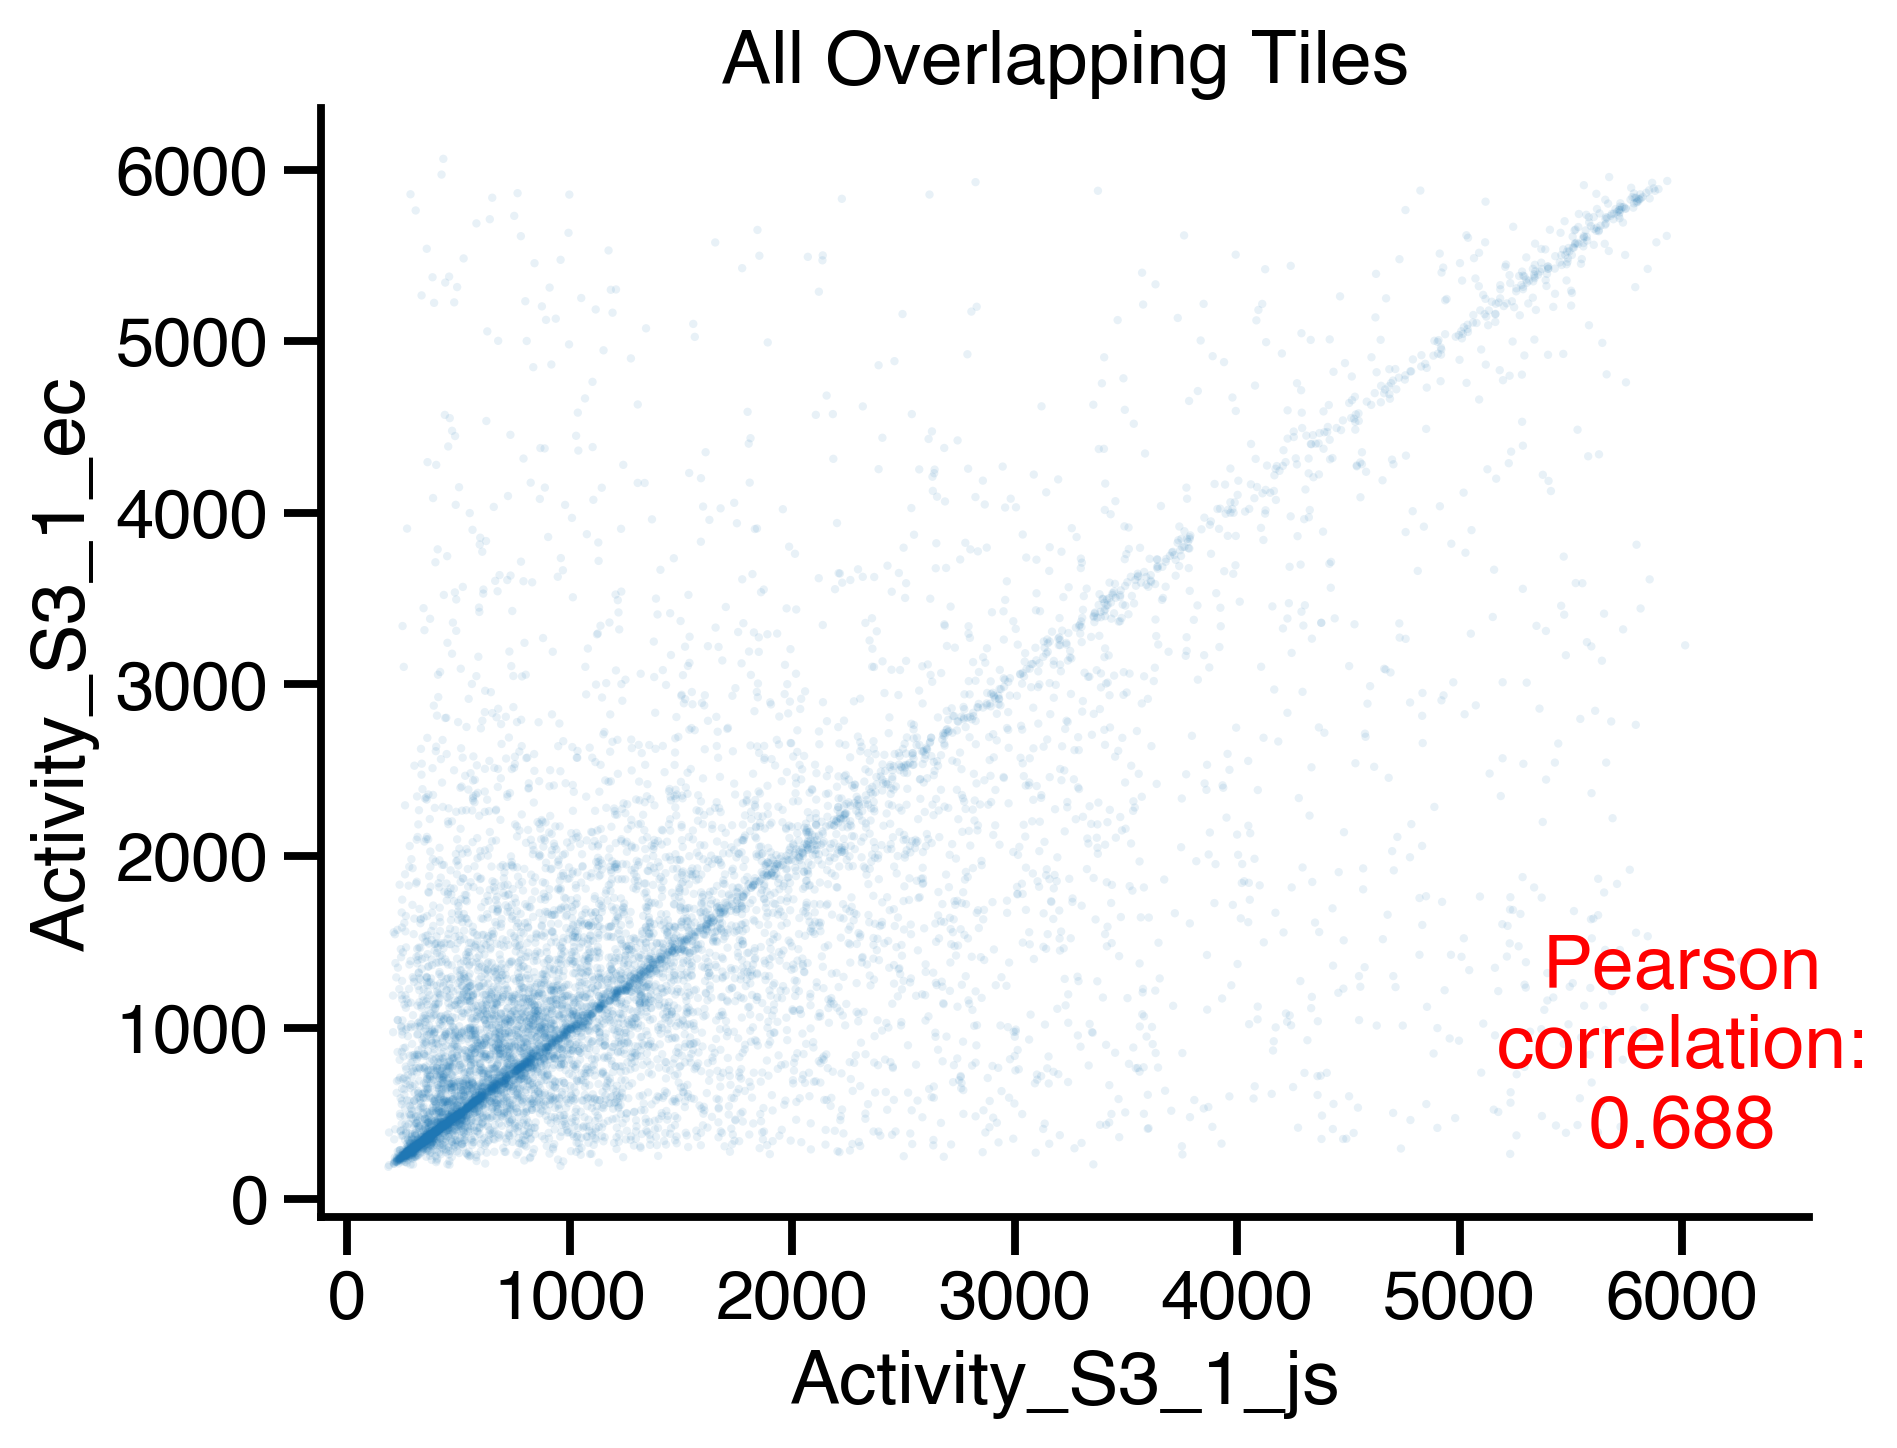

In [189]:
plt.figure(dpi = 300)
plot_correl("Activity_S3_1_js", "Activity_S3_1_ec")
plt.title("All Overlapping Tiles")

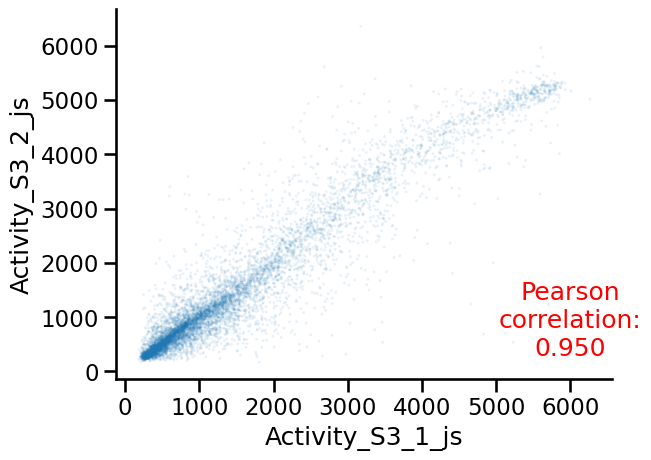

In [93]:
plot_correl("Activity_S3_1_js", "Activity_S3_2_js")

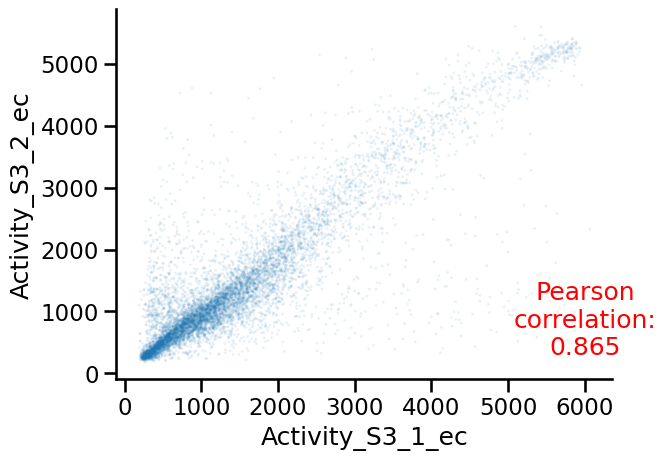

In [94]:
plot_correl("Activity_S3_1_ec", "Activity_S3_2_ec")

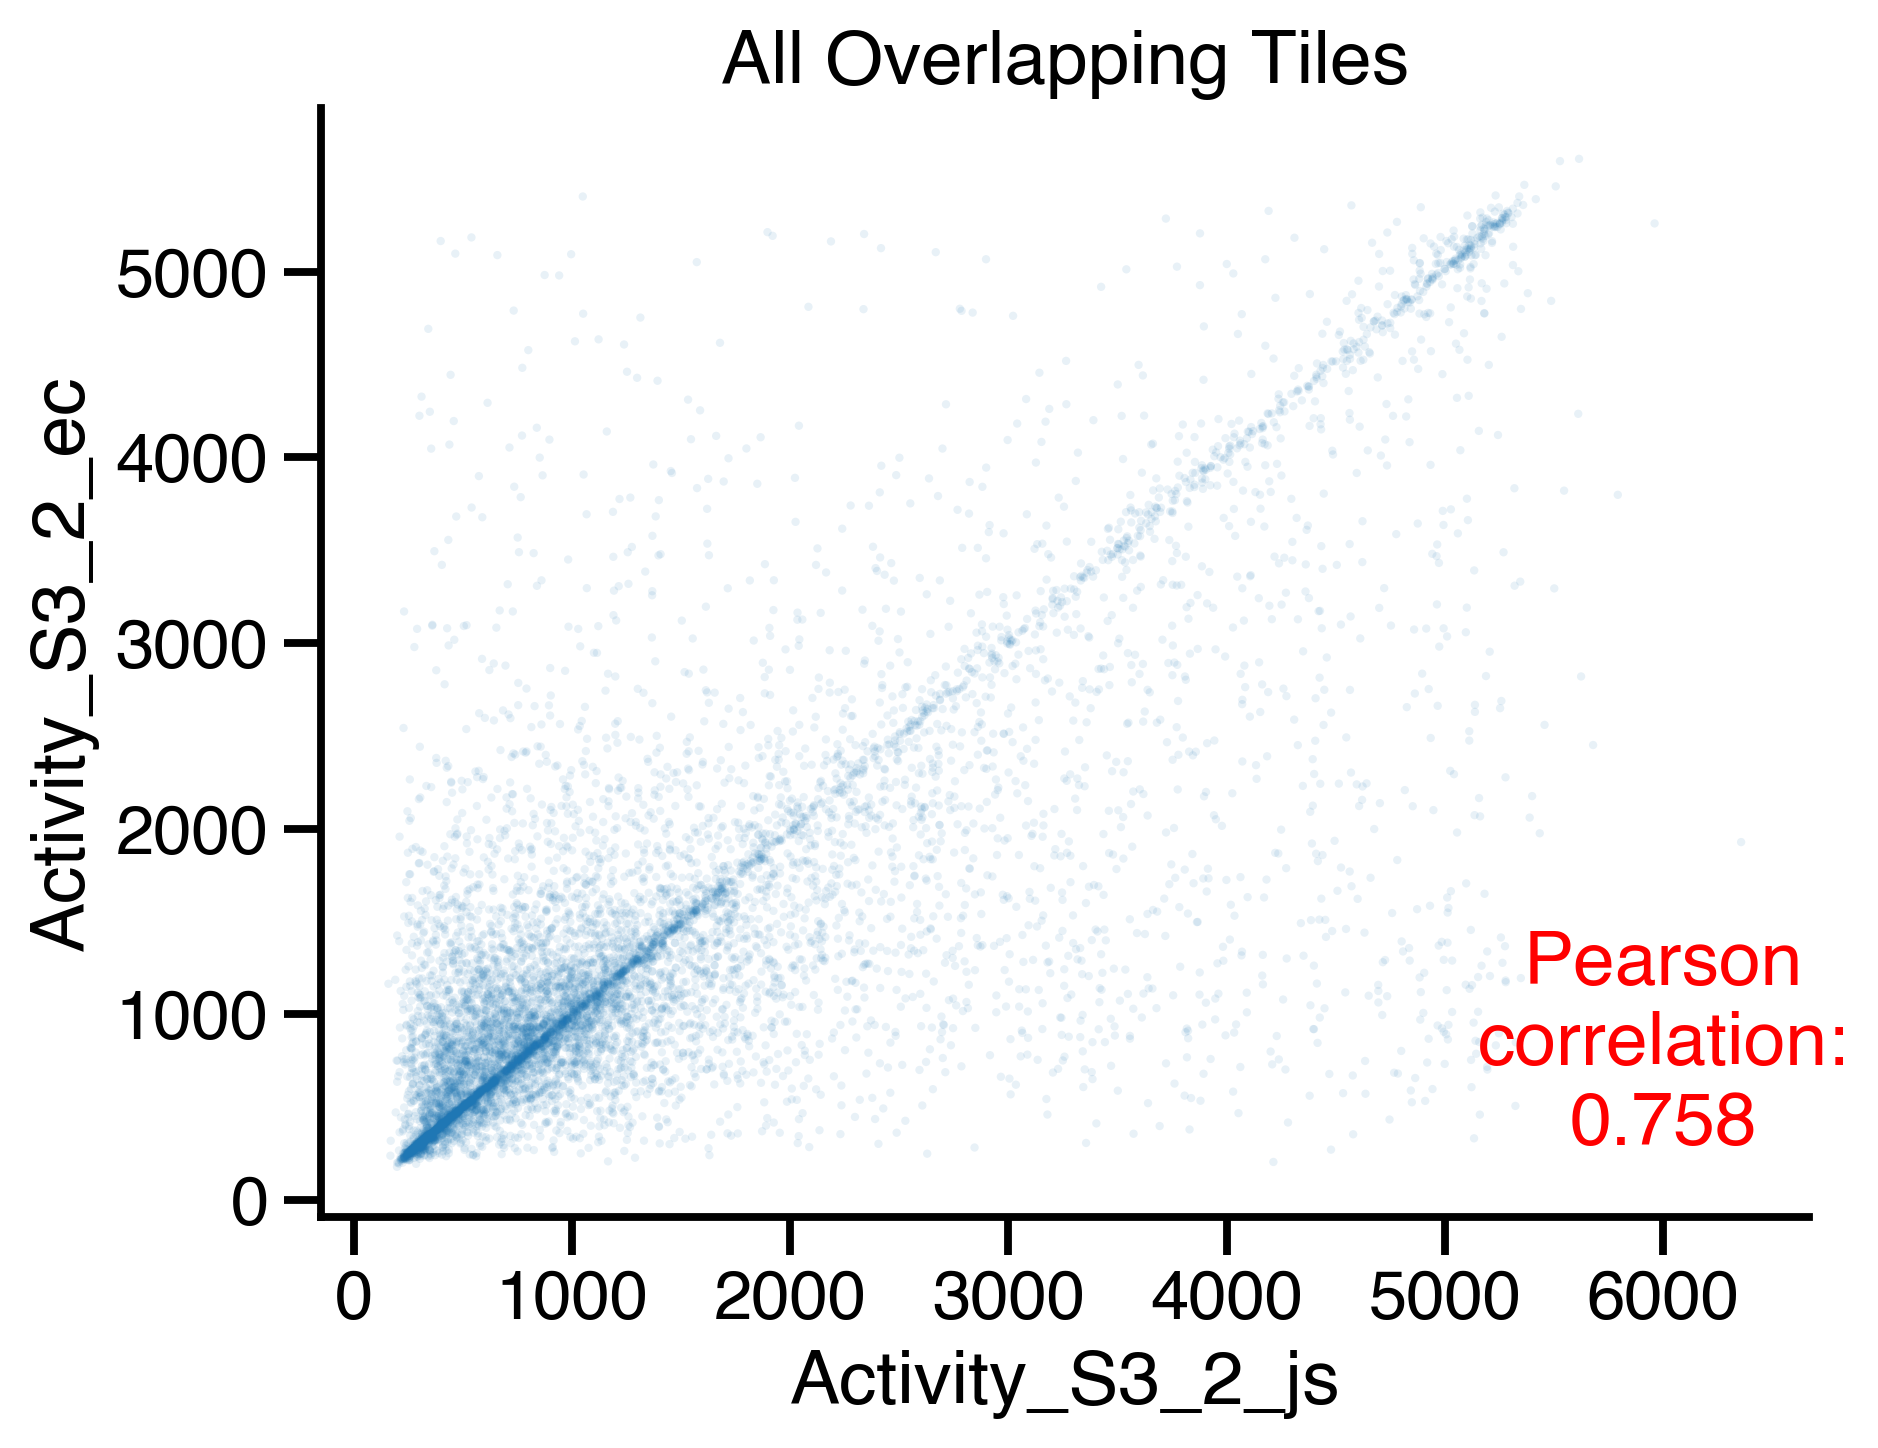

In [192]:
plt.figure(dpi = 300)
plt.title("All Overlapping Tiles")
plot_correl("Activity_S3_2_js", "Activity_S3_2_ec")

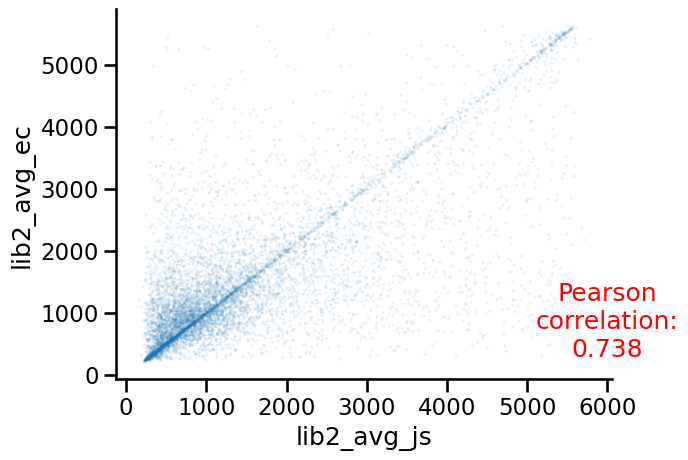

In [95]:
plot_correl("lib2_avg_js", "lib2_avg_ec")

## 3. Comparing reads

In [97]:
both

,ArrayDNA,Activity_GFP8,Activity_S3_1_js,Activity_S3_2_js,reads_S3_1_js,reads_S3_2_js,AAseq_js,lib2_avg_js,lib2_std_js,Activity_S3_1_ec,Activity_S3_2_ec,reads_S3_1_ec,reads_S3_2_ec,AAseq_ec,lib2_avg_ec,lib2_std_ec
0,ATTATTTGGCATTTGTTGGCTAAATCTGGTTTGTCTGGTTTGTCTT...,451.955540,553.464718,495.706275,12342.0,3089.0,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,524.585497,40.841386,444.761592,369.638636,21291.0,27676.0,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,407.200114,53.119951
1,CCATCTGATTATGTTTCTGCTCATGAAGTTTCTTTGGCTGAAACTT...,423.885353,551.450656,764.304915,16211.0,1899.0,PSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPE,657.877786,150.510690,749.687642,716.012754,17170.0,20078.0,PSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPE,732.850198,23.811742
2,GATTCTCATATTGCTTCTGATTATGTTACTCCATCTGATTATGTTT...,546.055903,544.271657,748.858276,21461.0,1105.0,DSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQP,646.564966,144.664585,1205.673067,921.201730,80.0,88.0,DSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQP,1063.437398,201.151612
3,CAATTTATCTTAAATTCTCAACAATTGGTTGAAGCTTTGTCTTTGT...,504.125469,525.528897,922.926861,4034.0,86.0,QFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPC,724.227879,281.002795,1516.022615,1985.812713,34.0,33.0,QFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPC,1750.917664,332.191764
4,TCTTTGGCTGAAACTTCTGAAGTTATGTGTATGGAAGATGAAGTTC...,383.458535,489.352841,1398.678654,3555.0,178.0,SLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAK,944.015747,642.990448,3495.779407,3769.355633,228.0,189.0,SLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAK,3632.567520,193.447605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9245,TTGGAACATGGTTTGGAAAGAGGTGCTAAAGAAATGTTGGATGATA...,NaN,NaN,3570.989020,NaN,11.0,LEHGLERGAKEMLDDKEEREKDRDRERRGEEDPTWFDSGS,3570.989020,NaN,3740.123701,3447.077589,84.0,73.0,LEHGLERGAKEMLDDKEEREKDRDRERRGEEDPTWFDSGS,3593.600645,207.214893
9246,GAAGATGAAGAATGGTTTGATGAAGAAGCTCAATTTATCTTGAATG...,NaN,NaN,3330.752810,NaN,13.0,EDEEWFDEEAQFILNAQQLVEALSLCDDLLGAQDREEEEN,3330.752810,NaN,3638.512152,3078.099946,102.0,111.0,EDEEWFDEEAQFILNAQQLVEALSLCDDLLGAQDREEEEN,3358.306049,396.271271
9247,ACTCAATCTCAATCTTCTAGATCTAGAAATATTCCACCACCACAAG...,NaN,NaN,5347.917675,NaN,11.0,TQSQSSRSRNIPPPQANSSRAREIGNGSKTTMVDEIPMSV,5347.917675,NaN,2346.224267,1195.355529,12.0,18.0,TQSQSSRSRNIPPPQANSSRAREIGNGSKTTMVDEIPMSV,1770.789898,813.787089
9248,GACTTTAAGAGAGATTTGGAAGAATGTCAGAAGATTGTCTTGGATC...,NaN,NaN,5545.836977,NaN,21.0,DFKRDLEECQKIVLDPSNIELRPDPETFLSQLEFGSQDSF,5545.836977,NaN,3816.517233,3820.398149,56.0,72.0,DFKRDLEECQKIVLDPSNIELRPDPETFLSQLEFGSQDSF,3818.457691,2.744222


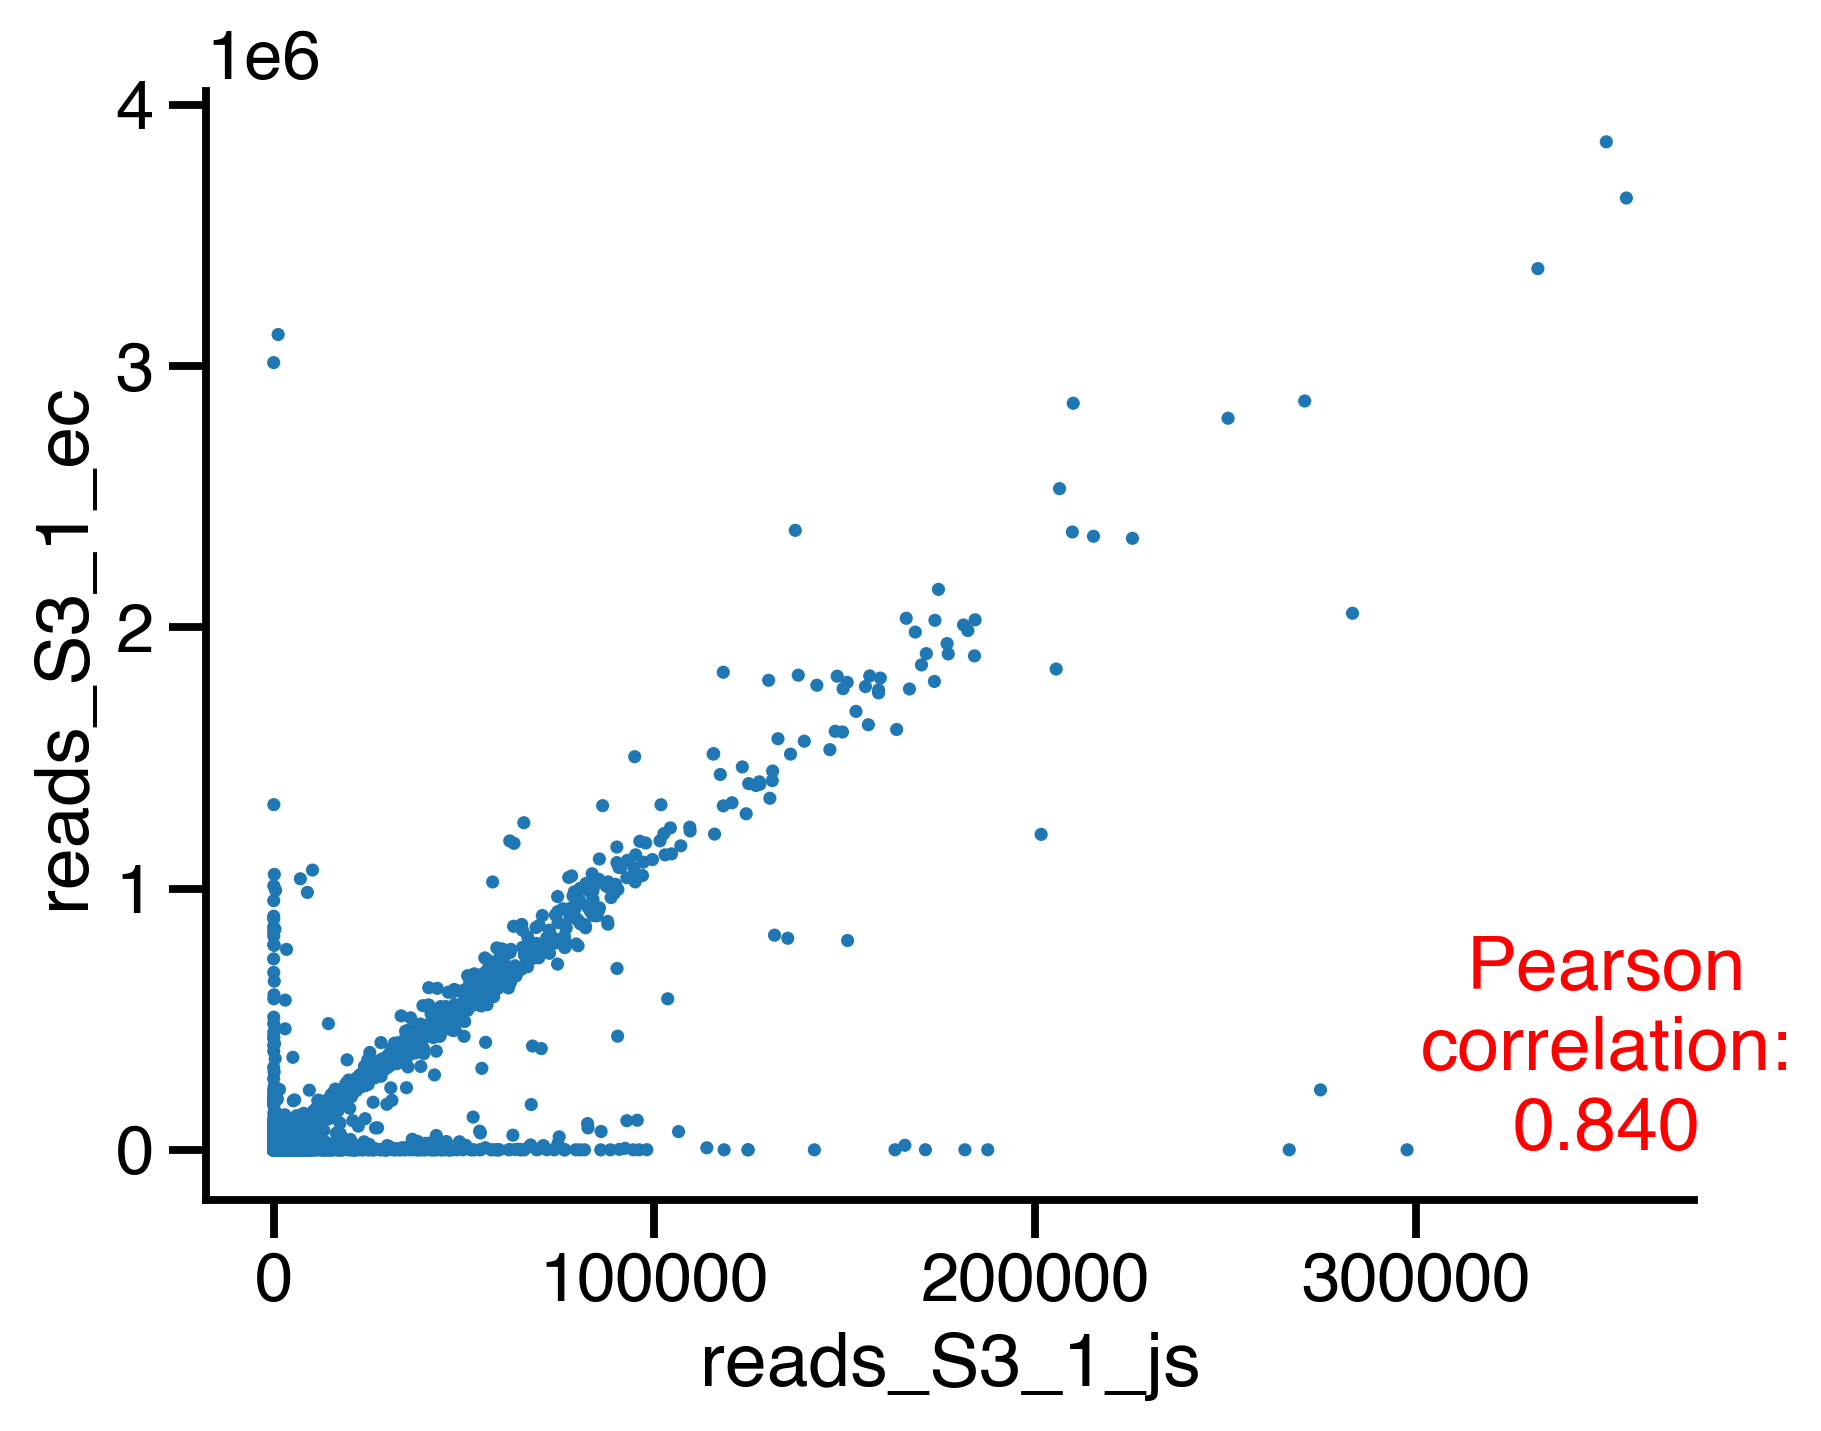

In [184]:
plt.figure(dpi = 300)
plot_correl("reads_S3_1_js", "reads_S3_1_ec", data = both, alpha = 1, s = 10, 
            text_x = 350000)

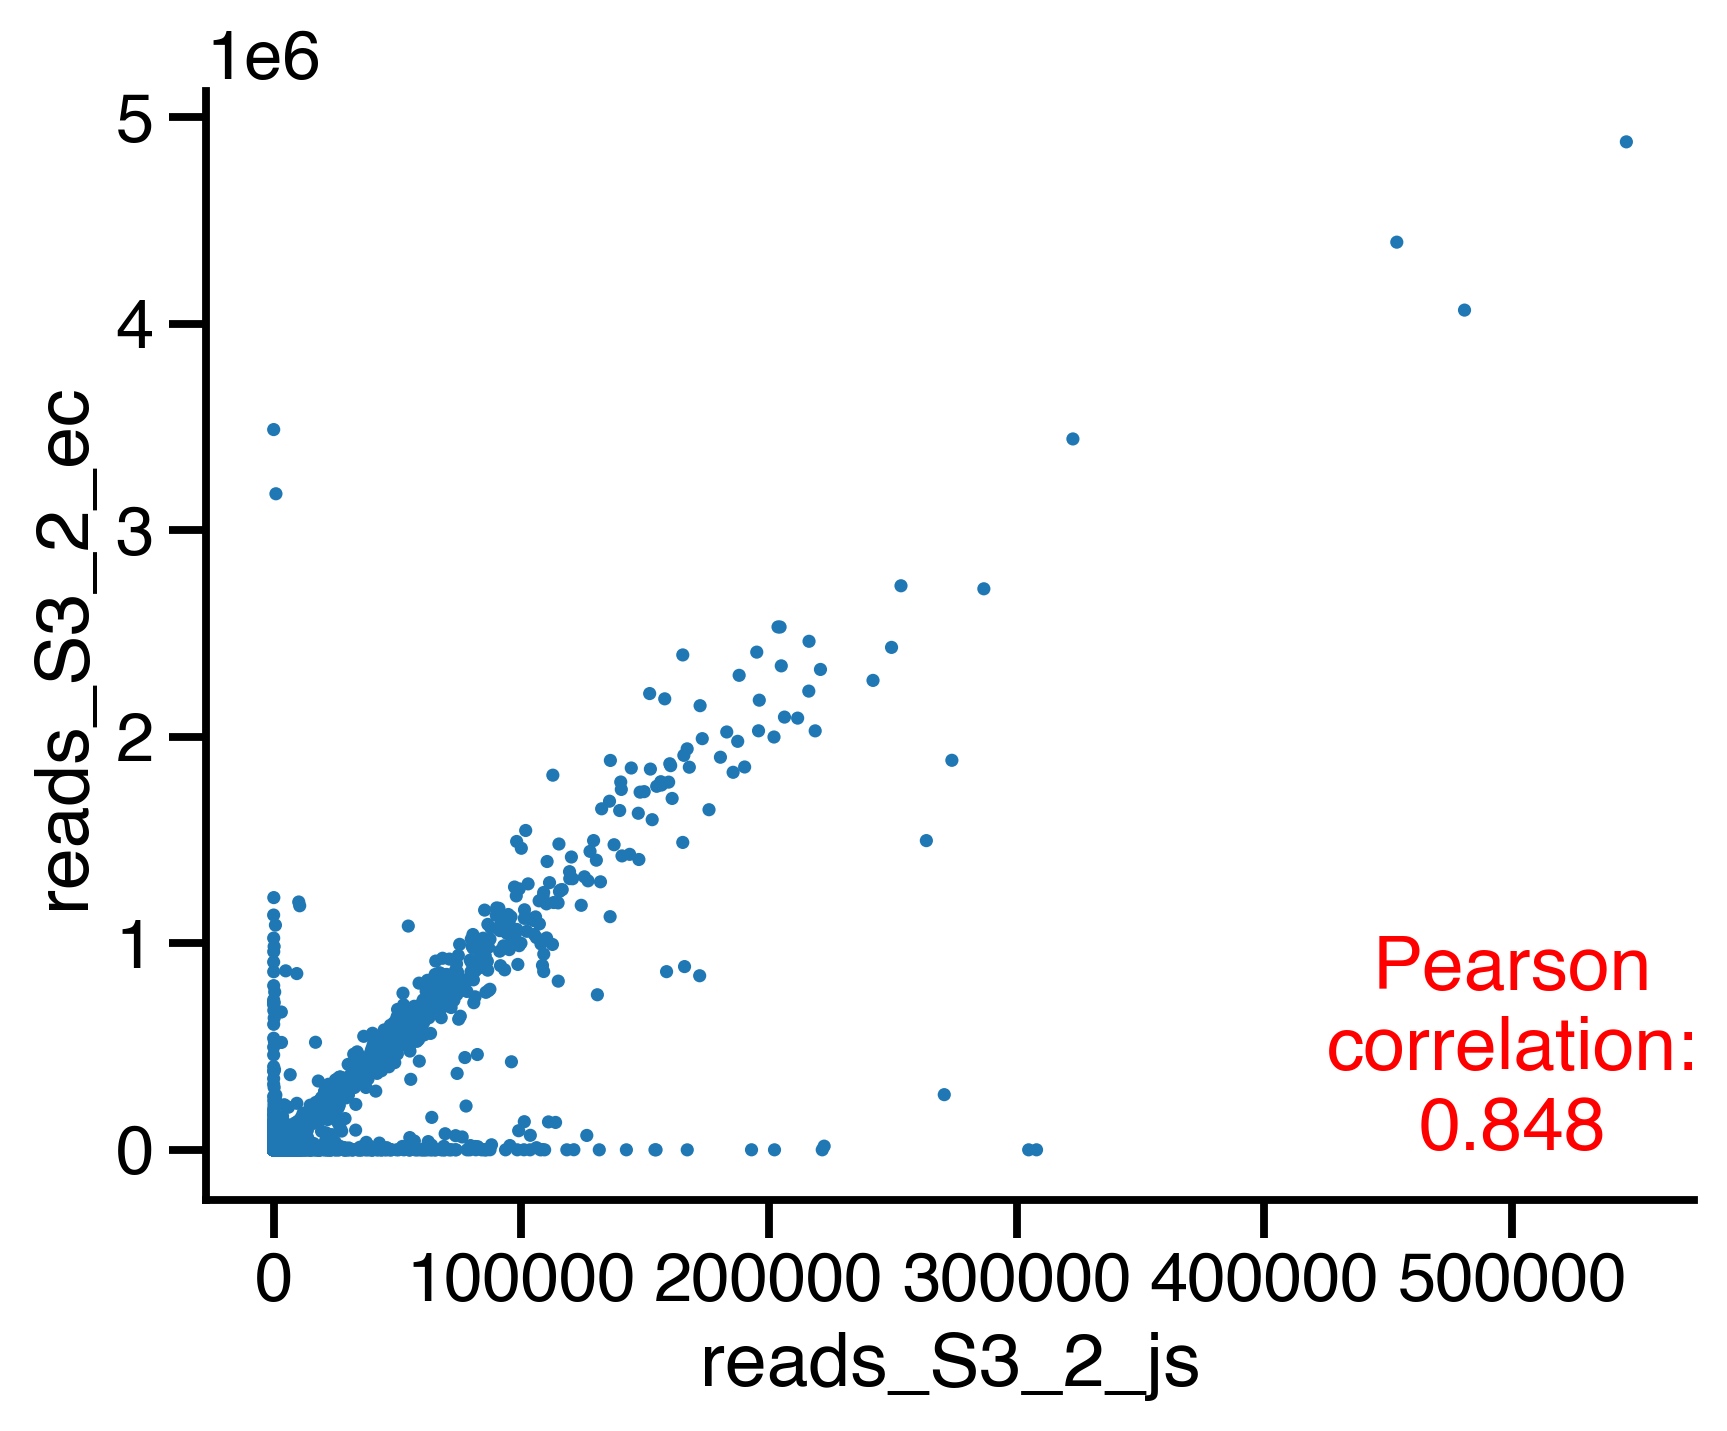

In [187]:
plt.figure(dpi = 300)
plot_correl("reads_S3_2_js", "reads_S3_2_ec", data = both, alpha = 1, s = 10, 
            text_x = 500000)

In [181]:
# sns.set_context('paper')
# sns.pairplot(both[["reads_S3_1_js", "reads_S3_2_js",
#                    "reads_S3_1_ec", "reads_S3_2_ec"]], 
#              plot_kws = {'s' : 2, 'edgecolor' : 'none', 'alpha' : 0.8},
#              diag_kws = {'bins' : 50}, 
#              corner = True,)

Which score is calculated with more reads?

In [121]:
np.mean(js_activities["reads_S3_1"])

6506.317355702017

In [122]:
np.mean(js_activities["reads_S3_2"])

6843.846033075151

In [123]:
np.mean(ec_activities["reads_S3_1"])

49286.31231658515

In [124]:
np.mean(ec_activities["reads_S3_2"])

53560.60611478634

EC's scores are calculated using many more reads

In [125]:
both

,ArrayDNA,Activity_GFP8,Activity_S3_1_js,Activity_S3_2_js,reads_S3_1_js,reads_S3_2_js,AAseq_js,lib2_avg_js,lib2_std_js,Activity_S3_1_ec,Activity_S3_2_ec,reads_S3_1_ec,reads_S3_2_ec,AAseq_ec,lib2_avg_ec,lib2_std_ec
0,ATTATTTGGCATTTGTTGGCTAAATCTGGTTTGTCTGGTTTGTCTT...,451.955540,553.464718,495.706275,12342.0,3089.0,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,524.585497,40.841386,444.761592,369.638636,21291.0,27676.0,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,407.200114,53.119951
1,CCATCTGATTATGTTTCTGCTCATGAAGTTTCTTTGGCTGAAACTT...,423.885353,551.450656,764.304915,16211.0,1899.0,PSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPE,657.877786,150.510690,749.687642,716.012754,17170.0,20078.0,PSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPE,732.850198,23.811742
2,GATTCTCATATTGCTTCTGATTATGTTACTCCATCTGATTATGTTT...,546.055903,544.271657,748.858276,21461.0,1105.0,DSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQP,646.564966,144.664585,1205.673067,921.201730,80.0,88.0,DSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQP,1063.437398,201.151612
3,CAATTTATCTTAAATTCTCAACAATTGGTTGAAGCTTTGTCTTTGT...,504.125469,525.528897,922.926861,4034.0,86.0,QFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPC,724.227879,281.002795,1516.022615,1985.812713,34.0,33.0,QFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPC,1750.917664,332.191764
4,TCTTTGGCTGAAACTTCTGAAGTTATGTGTATGGAAGATGAAGTTC...,383.458535,489.352841,1398.678654,3555.0,178.0,SLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAK,944.015747,642.990448,3495.779407,3769.355633,228.0,189.0,SLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAK,3632.567520,193.447605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9245,TTGGAACATGGTTTGGAAAGAGGTGCTAAAGAAATGTTGGATGATA...,NaN,NaN,3570.989020,NaN,11.0,LEHGLERGAKEMLDDKEEREKDRDRERRGEEDPTWFDSGS,3570.989020,NaN,3740.123701,3447.077589,84.0,73.0,LEHGLERGAKEMLDDKEEREKDRDRERRGEEDPTWFDSGS,3593.600645,207.214893
9246,GAAGATGAAGAATGGTTTGATGAAGAAGCTCAATTTATCTTGAATG...,NaN,NaN,3330.752810,NaN,13.0,EDEEWFDEEAQFILNAQQLVEALSLCDDLLGAQDREEEEN,3330.752810,NaN,3638.512152,3078.099946,102.0,111.0,EDEEWFDEEAQFILNAQQLVEALSLCDDLLGAQDREEEEN,3358.306049,396.271271
9247,ACTCAATCTCAATCTTCTAGATCTAGAAATATTCCACCACCACAAG...,NaN,NaN,5347.917675,NaN,11.0,TQSQSSRSRNIPPPQANSSRAREIGNGSKTTMVDEIPMSV,5347.917675,NaN,2346.224267,1195.355529,12.0,18.0,TQSQSSRSRNIPPPQANSSRAREIGNGSKTTMVDEIPMSV,1770.789898,813.787089
9248,GACTTTAAGAGAGATTTGGAAGAATGTCAGAAGATTGTCTTGGATC...,NaN,NaN,5545.836977,NaN,21.0,DFKRDLEECQKIVLDPSNIELRPDPETFLSQLEFGSQDSF,5545.836977,NaN,3816.517233,3820.398149,56.0,72.0,DFKRDLEECQKIVLDPSNIELRPDPETFLSQLEFGSQDSF,3818.457691,2.744222


## 4. S3_1 vs S3_2

Margot's slack response about S3 1 vs S3 2

That depends on the data:
- It is useful to start with comparing the activity of control tiles and wild type tiles between S3_1 and S3_2. If both are as expected, and matching the results from the first library sort from the first visit, then let's select one of the two based on tile diversity (see 2 bullet points below). If either S3_1 or S3_2 is diverging from what is expected for the control tiles, then we should continue with the one matching with expectations.
- If the number of unique tiles identified in S3_1 exceeds that of the sum of visit 1 sort library 1 and visit 2 sort S3_2 (mix of library 1 and 2), and  the activity of control tiles and wild type tiles look as expected than let's use S3_1. Remark that we will have to decide whether or not the presence of duplicates due to the mixing of the two libraries might have to be 'corrected for' during the analysis. Examples of duplicates include - amongst others - the basic wild type tiles and many of the phosphovariant tiles.
- If more tiles from library 2 are identified in visit 2 S3_2 than in visit 2 S3_1, then we should use S3_2. Remark that in order to compare results between the first and second library, thus comparing sorts from the first and second visit, we might have to scale the activity scores.

Plan:

1. Are both measurements similar?
- Control tiles S3_1 vs S3_2
- WT tiles S3_1 vs S3_2

2. Does S3_1 or S3_2 have more tiles from library 2?

In [209]:
BasicArTh = sog1_helpers.return_activities("BasicArTh", pos_regex = r'\.(\d+)')
BasicArTh.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,BasicArTh.1,Q6NQK2,1,21,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,1407.799127,1244.615820,1326.207474
1,BasicArTh.2,Q6NQK2,11,31,51,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4479.018364,3954.541874,4216.780119
2,BasicArTh.3,Q6NQK2,21,41,61,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,1434.266772,1013.665108,1223.965940


In [133]:
both_wt_meas = both[both["AAseq_ec"].isin(BasicArTh["tile"])]
both_wt_meas.head(3)

,ArrayDNA,Activity_GFP8,Activity_S3_1_js,Activity_S3_2_js,reads_S3_1_js,reads_S3_2_js,AAseq_js,lib2_avg_js,lib2_std_js,Activity_S3_1_ec,Activity_S3_2_ec,reads_S3_1_ec,reads_S3_2_ec,AAseq_ec,lib2_avg_ec,lib2_std_ec
0,ATTATTTGGCATTTGTTGGCTAAATCTGGTTTGTCTGGTTTGTCTT...,451.955540,553.464718,495.706275,12342.0,3089.0,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,524.585497,40.841386,444.761592,369.638636,21291.0,27676.0,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,407.200114,53.119951
1,CCATCTGATTATGTTTCTGCTCATGAAGTTTCTTTGGCTGAAACTT...,423.885353,551.450656,764.304915,16211.0,1899.0,PSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPE,657.877786,150.510690,749.687642,716.012754,17170.0,20078.0,PSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPE,732.850198,23.811742
2,GATTCTCATATTGCTTCTGATTATGTTACTCCATCTGATTATGTTT...,546.055903,544.271657,748.858276,21461.0,1105.0,DSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQP,646.564966,144.664585,1205.673067,921.201730,80.0,88.0,DSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQP,1063.437398,201.151612


Text(0.5, 1.0, 'WT Tiles')

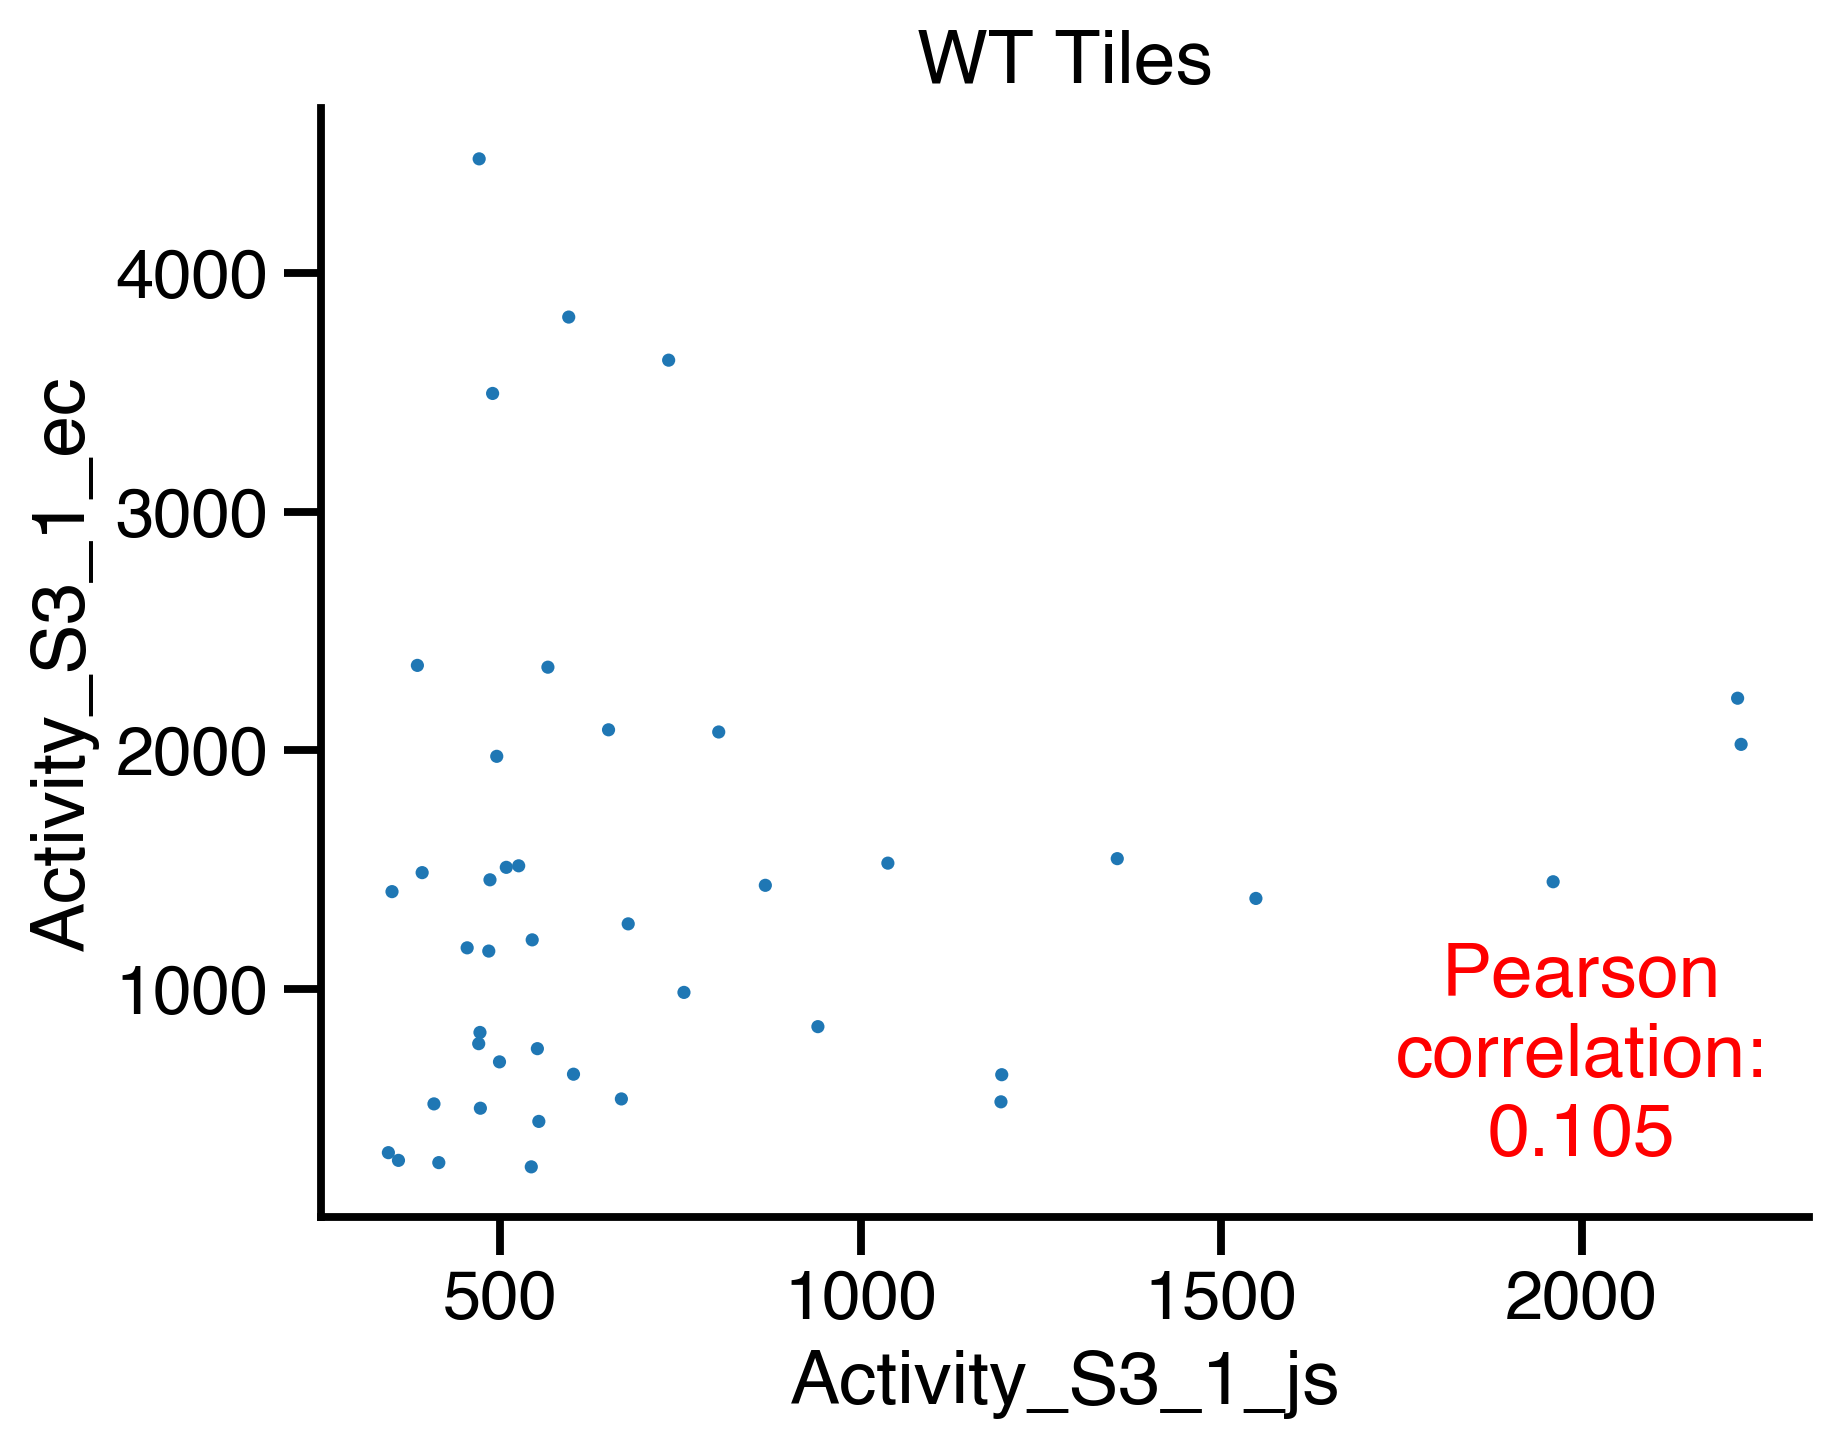

In [173]:
plt.figure(dpi = 300)
plot_correl("Activity_S3_1_js", "Activity_S3_1_ec", data = both_wt_meas, alpha = 1, s = 10, 
            text_x = 2000, text_y = 300)
plt.title("WT Tiles")

Text(0.5, 1.0, 'WT Tiles')

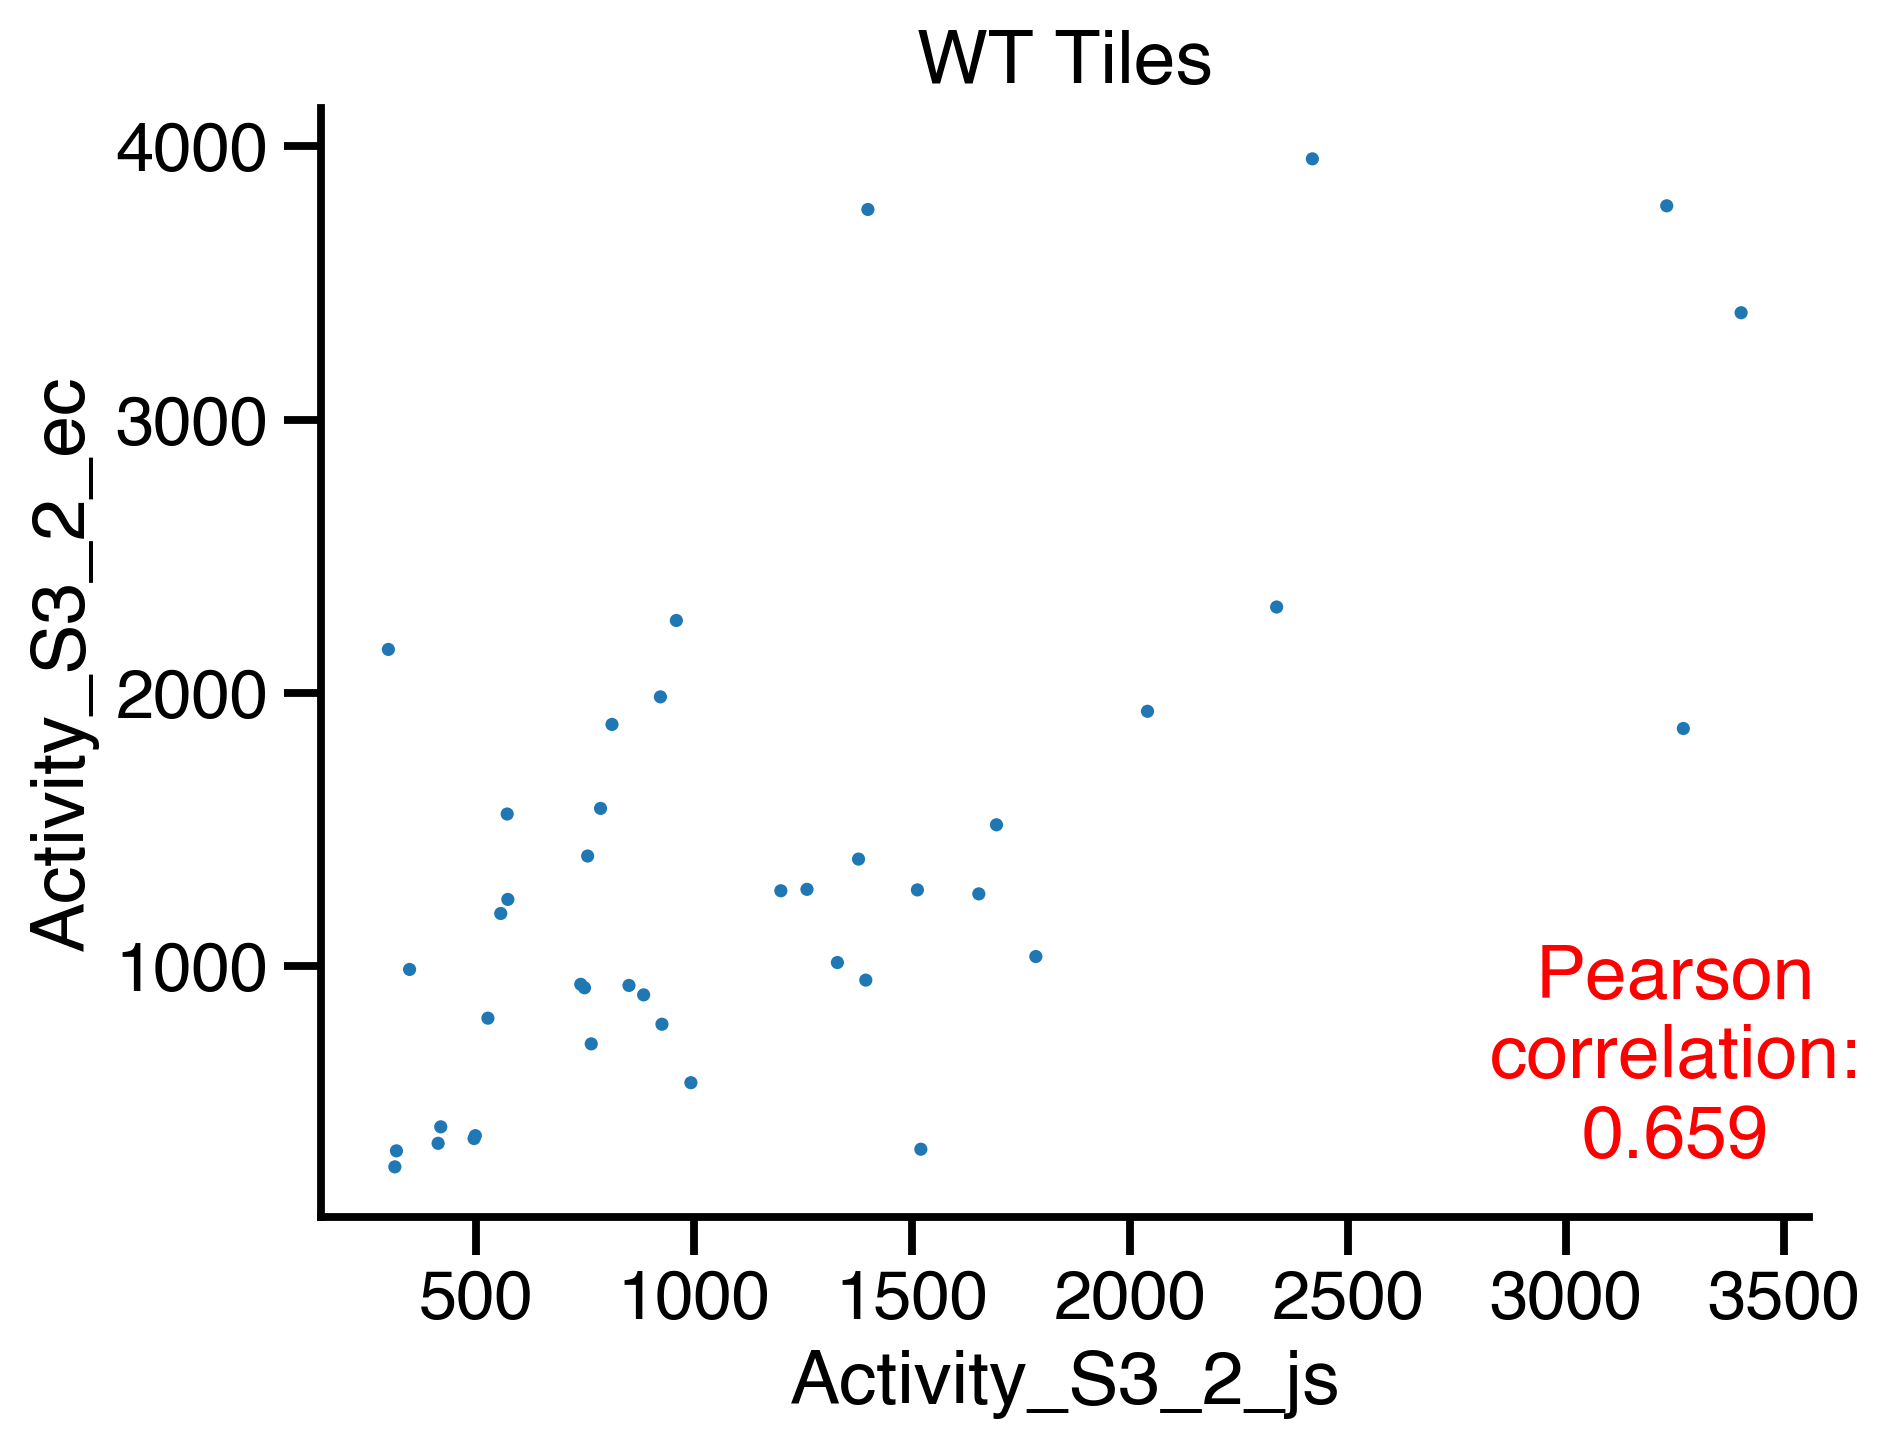

In [174]:
plt.figure(dpi = 300)
plot_correl("Activity_S3_2_js", "Activity_S3_2_ec", data = both_wt_meas, alpha = 1, s = 10, 
            text_x = 3250)
plt.title("WT Tiles")

In [150]:
control_seqs = pd.read_csv("../data/control_seqs.txt", sep = "\t")
control_seqs.head(3)

,Description,ProteinSeq,Other
0,AD1_0,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,GAL4_AD1_0
1,AD1_Aro2A_0,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,GAL4_AD1_Aro2A_0
2,AD1_L2A_0,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,GAL4_AD1_L2A_0


In [152]:
both_ctrl = both[both["AAseq_ec"].isin(control_seqs["ProteinSeq"])]
both_ctrl.head(3)

,ArrayDNA,Activity_GFP8,Activity_S3_1_js,Activity_S3_2_js,reads_S3_1_js,reads_S3_2_js,AAseq_js,lib2_avg_js,lib2_std_js,Activity_S3_1_ec,Activity_S3_2_ec,reads_S3_1_ec,reads_S3_2_ec,AAseq_ec,lib2_avg_ec,lib2_std_ec
13,GGTCCTAAGACTCCAGAAATTTCTTCTATGTTGGTTAATAATAATG...,371.839745,463.462358,1051.058599,12535.0,1324.0,GPKTPEISSMLVNNNEASFVEETNAAKKLKPNSDESDDLM,757.260478,415.493287,1034.893032,937.521672,1993.0,2291.0,GPKTPEISSMLVNNNEASFVEETNAAKKLKPNSDESDDLM,986.207352,68.851949
20,CCACCAACTGATGTTTCTGCTGGTGATGAAGCTCATGCTGATGGTG...,427.740464,1761.106655,1785.595379,36828.0,35369.0,PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP,1773.351017,17.316142,1815.392358,1787.619375,374802.0,376448.0,PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP,1801.505866,19.638464
32,TCTACTGATTCTACTCCAGCTGCTGAAGCTGAGAATGCTGAAGATA...,361.430211,971.751793,1854.974289,13184.0,7542.0,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,1413.363041,624.532616,1522.322628,1863.850546,74799.0,80249.0,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,1693.086587,241.496707


Text(0.5, 1.0, 'Control Tiles')

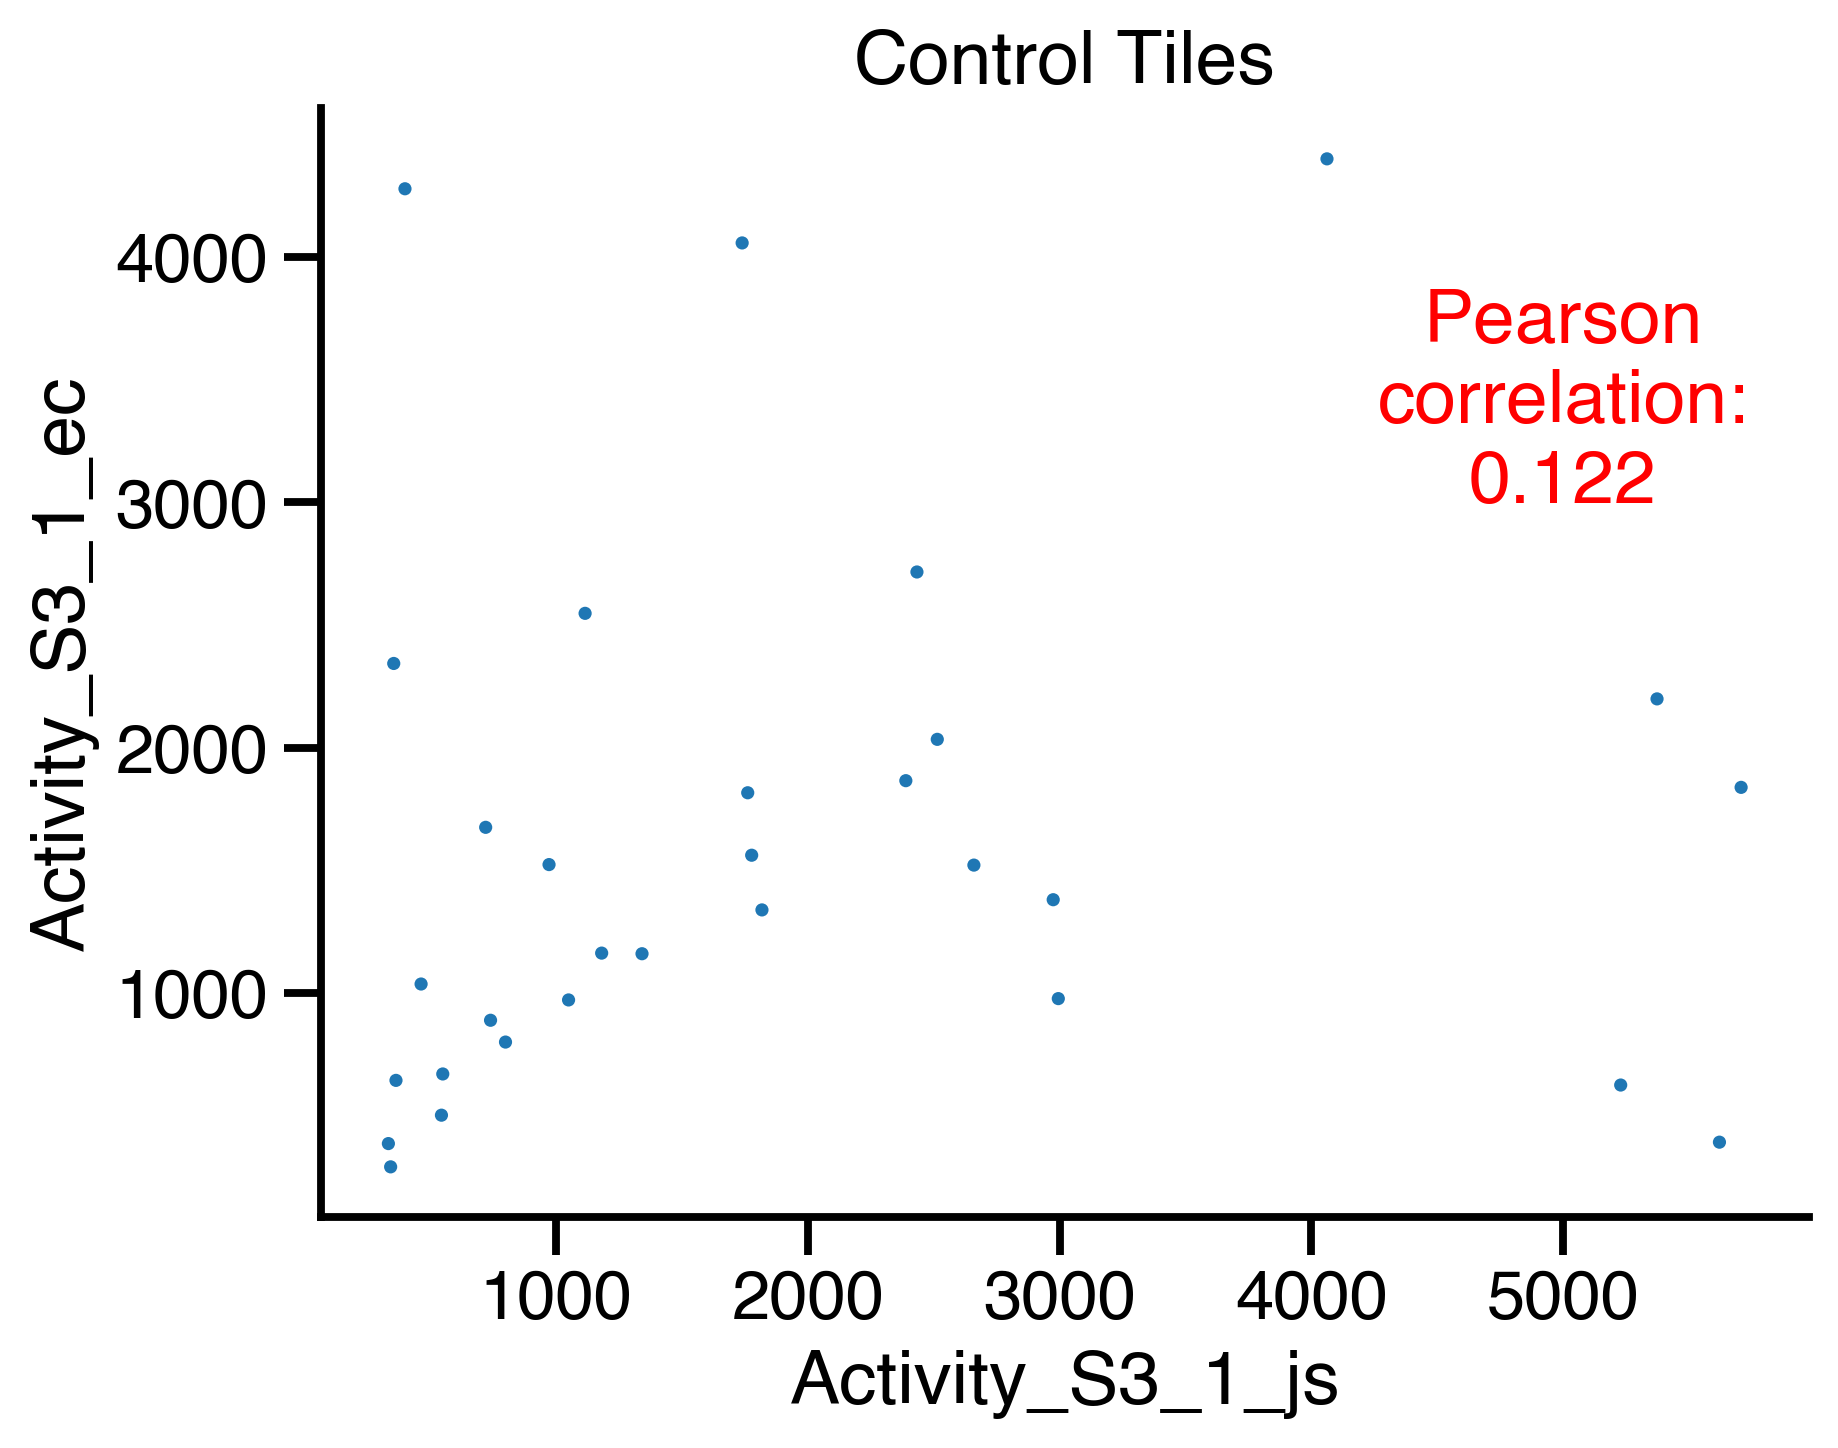

In [176]:
plt.figure(dpi = 300)
plot_correl("Activity_S3_1_js", "Activity_S3_1_ec", data = both_ctrl, alpha = 1, s = 10, text_x =5000, text_y = 3000)
plt.title("Control Tiles")

Text(0.5, 1.0, 'Control Tiles')

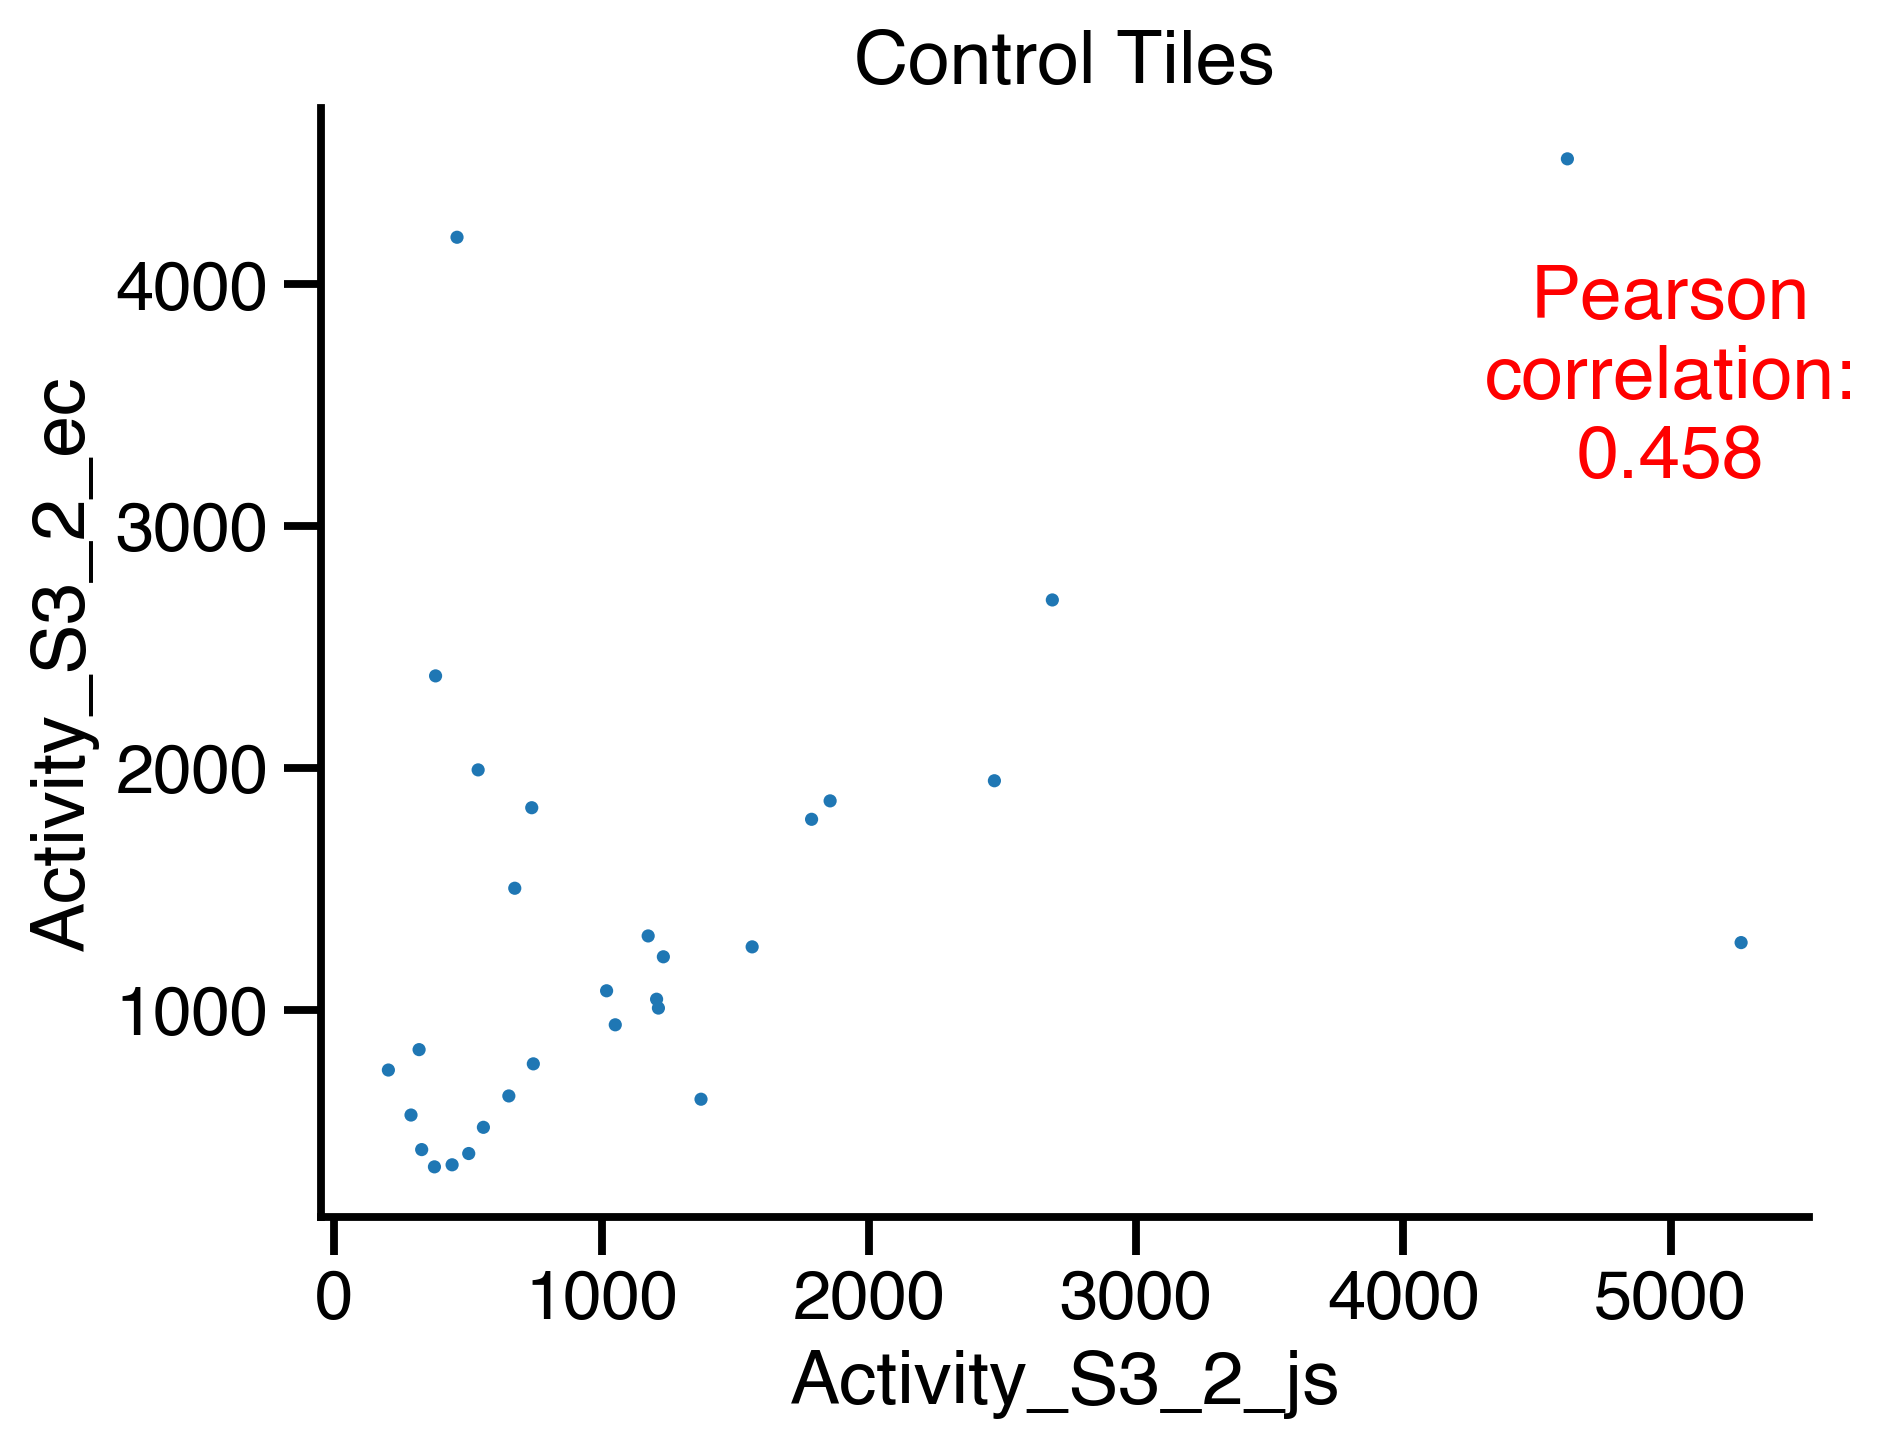

In [177]:
plt.figure(dpi = 300)
plot_correl("Activity_S3_2_js", "Activity_S3_2_ec", data = both_ctrl, alpha = 1, s = 10, text_x = 5000, text_y = 3200)
plt.title("Control Tiles")

## 5. Which has more measurements for library 2 members?

In [193]:
library = pd.read_excel("../margot_raw/SeqLib_Visit2_2023.xlsx", sheet_name = "Visit2")
library = library[["ProteinSeq", "Description", "Other"]]
library["Description"] = library["Description"].astype(str)

In [199]:
activities_EC = pd.read_csv("../data/Sog1_library2_activities_with_reads_ECspike.csv")
activities_EC

,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1079.074274,925.703811,610.0,643.0,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,1002.389042,108.449295
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1394.076068,1424.548173,44354.0,36001.0,KQRDNEDNGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1409.312120,21.547032
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,1371.861742,1170.193129,68.0,38.0,KQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRM,1271.027436,142.601244
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.663233,267.611412,5090.0,7330.0,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,275.637323,11.350351
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,4076.691936,3163.539743,172.0,137.0,KQIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,3620.115839,645.696108
...,...,...,...,...,...,...,...,...
11264,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,2314.792506,2111.813429,124.0,121.0,FDSPDVAESFETSPLFANADADLAGQDAWFSLFPSISGGE,2213.302968,143.527882
11265,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,4433.599889,4873.732571,6379.0,8831.0,FDWEPTDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,4653.666230,311.220804
11266,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1673.484641,1569.322449,816.0,769.0,FAAGARKRRKIHDDDFGDVRWHKAGRAKPVVLDGVQRGCK,1621.403545,73.653793
11267,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1780.391373,2360.015854,75.0,73.0,FVKDSLQDIGKYFEIDSTLDELEQVESGEGNDDLPDEEER,2070.203613,409.856401


In [202]:
#19,000 unique members of library
len(library["ProteinSeq"].unique())

19723

In [203]:
# We have measuremebts for 4,823 of these 19, 723
lib2_activities_EC = activities_EC[activities_EC["AAseq"].isin(library["ProteinSeq"])]
lib2_activities_EC

,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1079.074274,925.703811,610.0,643.0,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,1002.389042,108.449295
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,1371.861742,1170.193129,68.0,38.0,KQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRM,1271.027436,142.601244
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.663233,267.611412,5090.0,7330.0,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,275.637323,11.350351
5,AAACAACAACCATGCTTTGGTGATTATGCTCATTTGGGTGGTACTG...,1508.490533,1865.122581,163.0,209.0,KQQPCFGDYAHLGGTDDFKRDLEDCQKLVLDPCNIDLDTP,1686.806557,252.176940
13,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,1294.164331,1269.442354,26353.0,24153.0,KQDLEKCHELGLSDADFRLSQIEFSQDSCTAAWAGGNMLD,1281.803343,17.481077
...,...,...,...,...,...,...,...,...
11256,TTTGATCCATCTGATCCAGAAATTATTTGGCATTTGTTGGCTAAGA...,1865.912984,1733.697343,70.0,50.0,FDPSDPEIIWHLLAKTGSLGLTPHPFIDEFIPTVDQDDGI,1799.805163,93.490576
11264,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,2314.792506,2111.813429,124.0,121.0,FDSPDVAESFETSPLFANADADLAGQDAWFSLFPSISGGE,2213.302968,143.527882
11266,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1673.484641,1569.322449,816.0,769.0,FAAGARKRRKIHDDDFGDVRWHKAGRAKPVVLDGVQRGCK,1621.403545,73.653793
11267,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1780.391373,2360.015854,75.0,73.0,FVKDSLQDIGKYFEIDSTLDELEQVESGEGNDDLPDEEER,2070.203613,409.856401


In [204]:
lib2_activities_EC[["Activity_S3_1", "Activity_S3_2"]].isna().sum()

Activity_S3_1    11
Activity_S3_2    37
dtype: int64

# Sort 2

In [243]:
sort2 = pd.read_csv("../data/Sog1_all_activities_and_tiles_sort2.csv")
sort2 = sort2[["AAseq", "Activity_GFP4", "Activity_GFP8"]]
sort2

,AAseq,Activity_GFP4,Activity_GFP8
0,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,134.989378,351.546341
1,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,128.366712,341.380814
2,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,137.939253,428.862906
3,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,198.813066,417.236866
4,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,316.739307,759.332718
...,...,...,...
1708,PPTDVSLGDELHLDGEDVAMAHADALDDFDLDMLGDGDSP,1187.997671,2379.148243
1709,PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP,141.508642,427.740464
1710,GPKTPEISSMLVNNNEASFVEETNAAKKLKPNSDESDDLM,130.394881,371.839745
1711,VVSSAPSSSCLDFLWEENNPDTLLIDTQWLEDIIMGDANK,1437.644410,8118.586601


In [267]:
basic_sort2_vs_sort3 = pd.merge(BasicArTh, sort2, left_on = "tile", right_on = "AAseq").drop_duplicates()
basic_sort2_vs_sort3

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg,AAseq,Activity_GFP4,Activity_GFP8
0,BasicArTh.1,Q6NQK2,1,21,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,1407.799127,1244.615820,1326.207474,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,134.989378,351.546341
1,BasicArTh.2,Q6NQK2,11,31,51,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4479.018364,3954.541874,4216.780119,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,128.366712,341.380814
2,BasicArTh.3,Q6NQK2,21,41,61,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,1434.266772,1013.665108,1223.965940,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,137.939253,428.862906
3,BasicArTh.4,Q6NQK2,31,51,71,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,3815.896461,3782.725600,3799.311031,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,198.813066,417.236866
4,BasicArTh.5,Q6NQK2,41,61,81,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,538.931880,933.900949,736.416415,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,316.739307,759.332718
5,BasicArTh.6,Q6NQK2,51,71,91,VVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFI,1379.276161,1392.248129,1385.762145,VVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFI,1307.305276,1828.434887
6,BasicArTh.7,Q6NQK2,61,81,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,640.499185,1517.695164,1079.097175,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,876.926646,1483.665677
7,BasicArTh.8,Q6NQK2,71,91,111,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,444.761592,369.638636,407.200114,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,145.398077,451.955540
8,BasicArTh.9,Q6NQK2,81,101,121,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,3635.249963,1403.352788,2519.301376,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,195.947362,753.417479
9,BasicArTh.10,Q6NQK2,91,111,131,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,1974.901465,1577.686428,1776.293946,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,144.520104,494.021299


<Axes: xlabel='mid', ylabel='Activity_GFP8'>

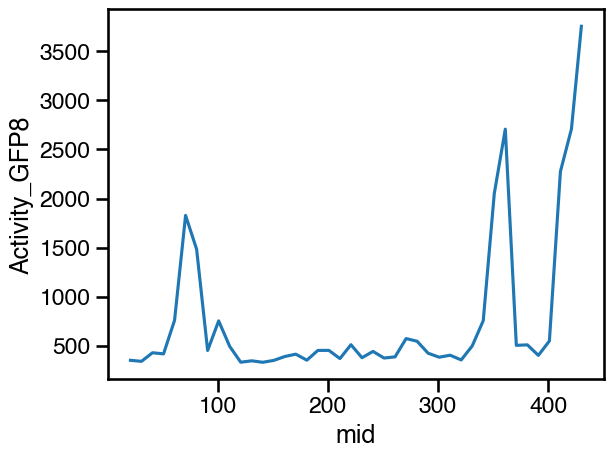

In [269]:
sns.lineplot(data = basic_sort2_vs_sort3, x = "mid", y = "Activity_GFP8")
#Matches what jordan saw!

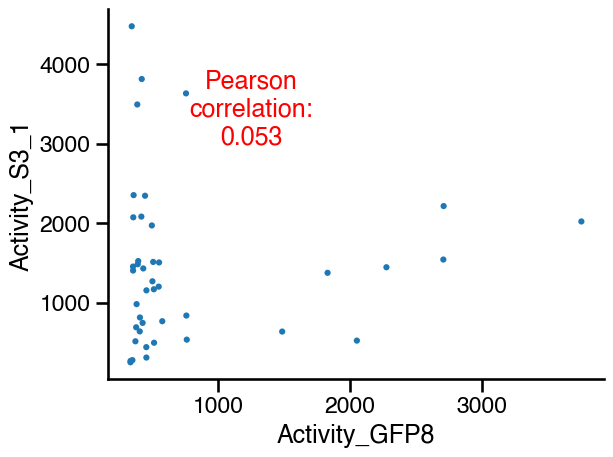

In [270]:
plot_correl("Activity_GFP8", "Activity_S3_1", basic_sort2_vs_sort3, alpha =1 , s = 20, text_x = 1250, text_y = 3000)

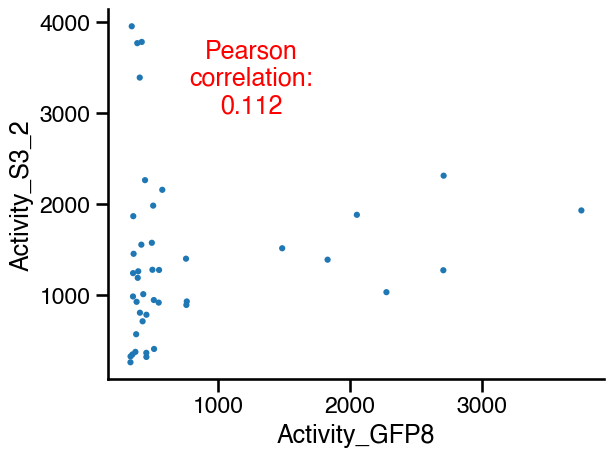

In [271]:
plot_correl("Activity_GFP8", "Activity_S3_2", basic_sort2_vs_sort3, alpha =1 , s = 20, text_x = 1250, text_y = 3000)

In [244]:
sort2_ec_sort3_overlap = pd.merge(ec_activities, sort2, on = "AAseq", suffixes = ("_s2", "_s3"))
sort2_ec_sort3_overlap

,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std,Activity_GFP4,Activity_GFP8
0,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTTGGT...,526.819049,1884.956669,55641.0,1291.0,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1205.887859,960.348320,860.220874,2050.765055
1,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTTGGT...,526.819049,1884.956669,55641.0,1291.0,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1205.887859,960.348320,860.220874,2050.765055
2,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTTGGT...,526.819049,1884.956669,55641.0,1291.0,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1205.887859,960.348320,860.220874,2050.765055
3,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTTGGT...,526.819049,1884.956669,55641.0,1291.0,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1205.887859,960.348320,860.220874,2050.765055
4,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTTGGT...,526.819049,1884.956669,55641.0,1291.0,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1205.887859,960.348320,860.220874,2050.765055
...,...,...,...,...,...,...,...,...,...,...
189,TTGGAACATGGTTTGGAGAATGGTGCTAAAGAAATGTTGGATGATA...,1272.738581,1281.496172,21232.0,22407.0,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,1277.117377,6.192552,173.553098,498.425378
190,TTGGAACATGGTTTGGAGAATGGTGCTAAAGAAATGTTGGATGATA...,1272.738581,1281.496172,21232.0,22407.0,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,1277.117377,6.192552,173.553098,498.425378
191,TTGGAACATGGTTTGGAGAATGGTGCTAAAGAAATGTTGGATGATA...,1272.738581,1281.496172,21232.0,22407.0,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,1277.117377,6.192552,173.553098,498.425378
192,TTGGAACATGGTTTGGAGAATGGTGCTAAAGAAATGTTGGATGATA...,1272.738581,1281.496172,21232.0,22407.0,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,1277.117377,6.192552,173.553098,498.425378


<Figure size 5760x4320 with 0 Axes>

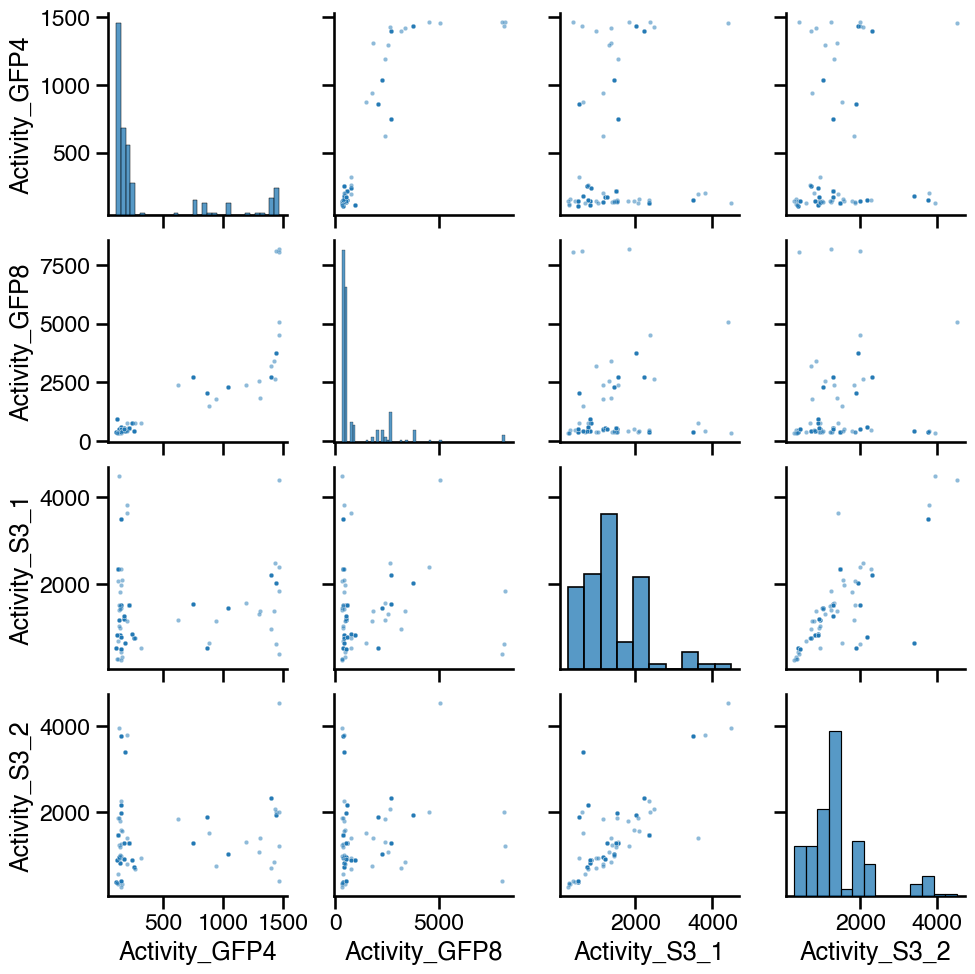

In [335]:
plt.figure(dpi = 900)
sns.pairplot(sort2_ec_sort3_overlap[["Activity_GFP4", "Activity_GFP8", "Activity_S3_1", "Activity_S3_2"]], plot_kws = {"s" : 10, "alpha" : 0.5})

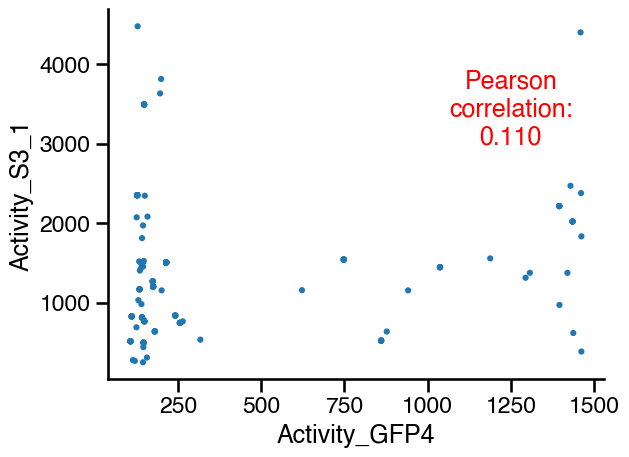

In [261]:
plot_correl("Activity_GFP4", "Activity_S3_1", sort2_ec_sort3_overlap, alpha =1 , s = 20, text_x = 1250, text_y = 3000)

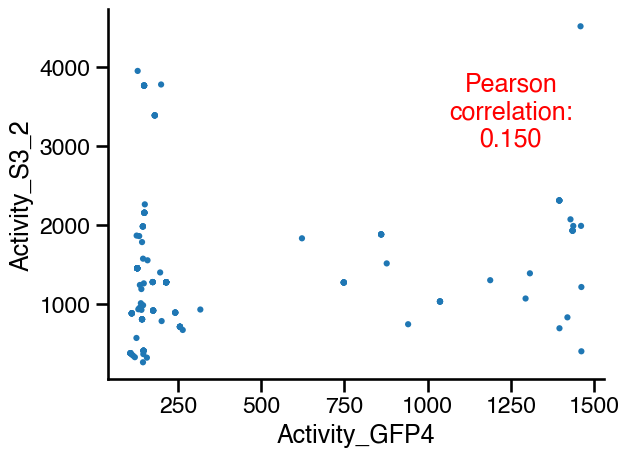

In [262]:
plot_correl("Activity_GFP4", "Activity_S3_2", sort2_ec_sort3_overlap, alpha =1 , s = 20, text_x = 1250, text_y = 3000)

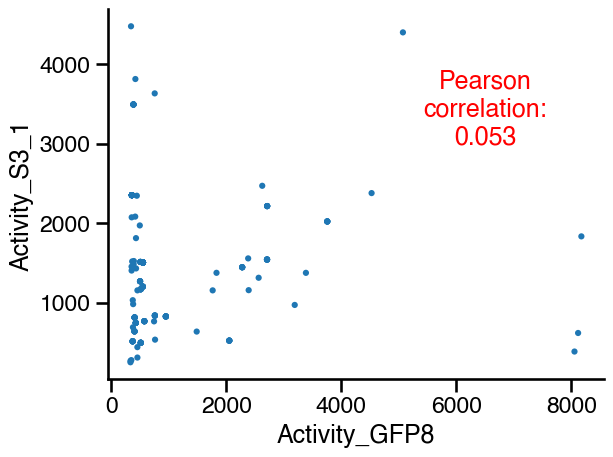

In [273]:
plot_correl("Activity_GFP8", "Activity_S3_1", sort2_ec_sort3_overlap, alpha =1 , s = 20, text_x = 6500, text_y = 3000)

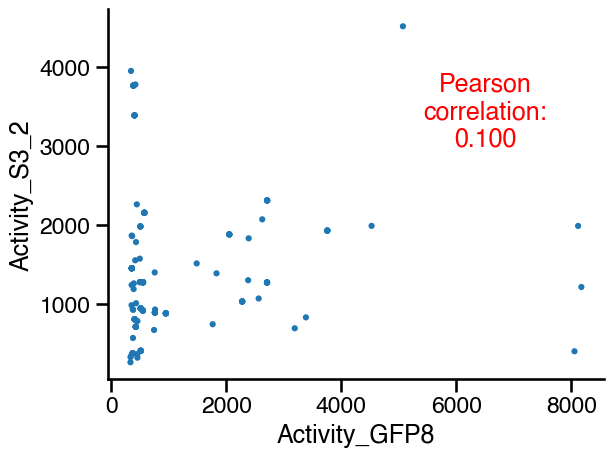

In [274]:
plot_correl("Activity_GFP8", "Activity_S3_2", sort2_ec_sort3_overlap, alpha =1 , s = 20, text_x = 6500, text_y = 3000)

In [278]:
library_sort_2 = pd.merge(library, sort2, left_on = "ProteinSeq", right_on = "AAseq").drop_duplicates()
library_sort_2

,ProteinSeq,Description,Other,AAseq,Activity_GFP4,Activity_GFP8
0,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,1459.479593,5071.236824
1,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,1396.157808,3188.980214
2,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_7As_0,GCN4_CAAD40_7As_0,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,132.973246,361.430211
3,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,Cterm_0,War1_Cterm_0,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,1462.000000,8175.449534
4,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,alt_0,GCN4alt_0,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,1462.000000,8055.707854
...,...,...,...,...,...,...
1841,EDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,35_PSvsCHA_DD35_S372_PShDbg.1,NaN,EDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,747.873344,2707.339022
1847,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,35_PSvsCHA_DD35_S372_PShDbg.2,NaN,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,1461.113539,7749.057090
1854,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,35_PSvsCHA_DD35_S372_PShDbg.3,NaN,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,1461.113539,7749.057090
1861,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,35_PSvsCHA_DD35_S372_PShDbg.111,NaN,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,1461.113539,7749.057090


In [305]:
library_sort_2["Description"].str.split("_").str[1].value_counts()

Description
PSv        126
HFB         74
PSh         60
PSvsCHA     28
PSbb        24
PSd         15
CHA         14
0            6
PSsubst      4
LOW          3
PsV          2
7As          1
WT           1
Name: count, dtype: int64

In [284]:
PSv_conf2fA_STYA = sog1_helpers.return_activities("PSv_conf2fA_STYA")
PSv_conf2fA_STYA

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,7_PSv_conf2fA_STYA,NaN,61,81,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,589.233964,567.661610,578.447787
1,8_PSv_conf2fA_STYA,NaN,71,91,111,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2073.520699,2127.003654,2100.262176
2,9_PSv_conf2fA_STYA,NaN,81,101,121,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1469.859938,1112.678850,1291.269394
3,10_PSv_conf2fA_STYA,NaN,91,111,131,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2016.437518,1159.883146,1588.160332
4,21_PSv_conf2fA_STYA,NaN,201,221,241,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,2506.268941,2002.619268,2254.444104
5,22_PSv_conf2fA_STYA,NaN,211,231,251,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVAPKLAAP,3424.426298,3241.749707,3333.088003
6,23_PSv_conf2fA_STYA,NaN,221,241,261,GDKAEQEVSEDIFAAVAPTADPVAPKLAAPEPRNAVRICS,1388.705299,942.209124,1165.457211
7,24_PSv_conf2fA_STYA,NaN,231,251,271,DIFAAVAPTADPVAPKLAAPEPRNAVRICSDSHIASDYVT,626.422487,749.661133,688.041810
8,25_PSv_conf2fA_STYA,NaN,241,261,281,DPVAPKLAAPEPRNAVRICSDSHIASDYVTPSDYVSAHEV,1727.531800,1233.415453,1480.473626
9,32_PSv_conf2fA_STYA,NaN,311,331,351,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGA,NaN,NaN,NaN


In [286]:
sort2_PSv_conf2fA_STYA = library_sort_2[library_sort_2["Description"].str.contains("PSv_conf2fA_STYA")]
sort2_PSv_conf2fA_STYA

,ProteinSeq,Description,Other,AAseq,Activity_GFP4,Activity_GFP8
547,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGA,32_PSv_conf2fA_STYA,NaN,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGA,152.565384,397.343096
556,EMLDDKEEQEKDRDNENQGEEDPTWFDSGAQFILNAQQLV,33_PSv_conf2fA_STYA,NaN,EMLDDKEEQEKDRDNENQGEEDPTWFDSGAQFILNAQQLV,265.560948,914.784601
562,KDRDNENQGEEDPTWFDSGAQFILNAQQLVEALSLCDDLL,34_PSv_conf2fA_STYA,NaN,KDRDNENQGEEDPTWFDSGAQFILNAQQLVEALSLCDDLL,232.184778,692.427971
568,EDPTWFDSGAQFILNAQQLVEALSLCDDLLGAQDREENTN,35_PSv_conf2fA_STYA,NaN,EDPTWFDSGAQFILNAQQLVEALSLCDDLLGAQDREENTN,110.556780,947.091660
575,GAQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,38_PSv_conf2fA_STYA,NaN,GAQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,160.386247,423.508314
584,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDAPPEFRLA,40_PSv_conf2fA_STYA,NaN,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDAPPEFRLA,883.873434,1611.432773
590,QKIVLDPSNIELDAPPEFRLAQLEFGAQDSFLAWGTGKTD,42_PSv_conf2fA_STYA,NaN,QKIVLDPSNIELDAPPEFRLAQLEFGAQDSFLAWGTGKTD,1383.172936,2765.424764


In [290]:
PSv_conf2fD = sog1_helpers.return_activities("PSv_conf2fD")
PSv_conf2fD

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,7_PSv_conf2fD,/,61,81,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPDVNQD,612.310337,525.559638,568.934988
1,8_PSv_conf2fD,/,71,91,111,IIWHLLAKSGLSGLSSHPFIDEFIPDVNQDDGICYTHPKN,1330.105073,964.886411,1147.495742
2,9_PSv_conf2fD,/,81,101,121,LSGLSSHPFIDEFIPDVNQDDGICYTHPKNLPGVKSDGTV,3366.486424,3734.635082,3550.560753
3,10_PSv_conf2fD,/,91,111,131,DEFIPDVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,1617.016395,1028.150576,1322.583486
4,21_PSv_conf2fD,/,201,221,241,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVDPTA,534.506033,788.330165,661.418099
5,22_PSv_conf2fD,/,211,231,251,QQPQQLVVKRGDKAEQEVSEDIFAAVDPTADPVDPKLADP,1668.444047,1244.981802,1456.712924
6,23_PSv_conf2fD,/,221,241,261,GDKAEQEVSEDIFAAVDPTADPVDPKLADPEPRNAVRICS,2732.816163,2570.852747,2651.834455
7,24_PSv_conf2fD,/,231,251,271,DIFAAVDPTADPVDPKLADPEPRNAVRICSDSHIASDYVT,1247.551307,1219.135527,1233.343417
8,25_PSv_conf2fD,/,241,261,281,DPVDPKLADPEPRNAVRICSDSHIASDYVTPSDYVSAHEV,1893.155849,1347.526513,1620.341181
9,32_PSv_conf2fD,/,311,331,351,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGD,NaN,NaN,NaN


In [291]:
sort2_PSv_conf2fD = library_sort_2[library_sort_2["Description"].str.contains("PSv_conf2fD")]
sort2_PSv_conf2fD

,ProteinSeq,Description,Other,AAseq,Activity_GFP4,Activity_GFP8
762,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGD,32_PSv_conf2fD,/,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGD,135.671157,419.602126
771,EMLDDKEEQEKDRDNENQGEEDPTWFDSGDQFILNDQQLV,33_PSv_conf2fD,/,EMLDDKEEQEKDRDNENQGEEDPTWFDSGDQFILNDQQLV,329.666908,908.952754
777,KDRDNENQGEEDPTWFDSGDQFILNDQQLVEALSLCDDLL,34_PSv_conf2fD,/,KDRDNENQGEEDPTWFDSGDQFILNDQQLVEALSLCDDLL,1451.313618,7995.935881
783,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,35_PSv_conf2fD,/,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,1461.113539,7749.057090
790,GDQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,38_PSv_conf2fD,/,GDQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,125.606347,414.538730
799,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDDPPEFRLD,40_PSv_conf2fD,/,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDDPPEFRLD,990.404175,2132.907678
805,QKIVLDPSNIELDDPPEFRLDQLEFGDQDSFLAWGTGKTD,42_PSv_conf2fD,/,QKIVLDPSNIELDDPPEFRLDQLEFGDQDSFLAWGTGKTD,1458.478442,7168.293183


In [287]:
pd.merge(PSv_conf2fA_STYA, sort2_PSv_conf2fA_STYA)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg,ProteinSeq,AAseq,Activity_GFP4,Activity_GFP8
0,32_PSv_conf2fA_STYA,NaN,311,331,351,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGA,NaN,NaN,NaN,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGA,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGA,152.565384,397.343096
1,33_PSv_conf2fA_STYA,NaN,321,341,361,EMLDDKEEQEKDRDNENQGEEDPTWFDSGAQFILNAQQLV,NaN,NaN,NaN,EMLDDKEEQEKDRDNENQGEEDPTWFDSGAQFILNAQQLV,EMLDDKEEQEKDRDNENQGEEDPTWFDSGAQFILNAQQLV,265.560948,914.784601
2,34_PSv_conf2fA_STYA,NaN,331,351,371,KDRDNENQGEEDPTWFDSGAQFILNAQQLVEALSLCDDLL,NaN,NaN,NaN,KDRDNENQGEEDPTWFDSGAQFILNAQQLVEALSLCDDLL,KDRDNENQGEEDPTWFDSGAQFILNAQQLVEALSLCDDLL,232.184778,692.427971
3,35_PSv_conf2fA_STYA,NaN,341,361,381,EDPTWFDSGAQFILNAQQLVEALSLCDDLLGAQDREENTN,830.835338,885.595129,858.215234,EDPTWFDSGAQFILNAQQLVEALSLCDDLLGAQDREENTN,EDPTWFDSGAQFILNAQQLVEALSLCDDLLGAQDREENTN,110.556780,947.091660
4,38_PSv_conf2fA_STYA,NaN,371,391,411,GAQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,NaN,NaN,NaN,GAQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,GAQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,160.386247,423.508314
5,40_PSv_conf2fA_STYA,NaN,391,411,431,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDAPPEFRLA,NaN,NaN,NaN,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDAPPEFRLA,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDAPPEFRLA,883.873434,1611.432773
6,42_PSv_conf2fA_STYA,NaN,410,430,450,QKIVLDPSNIELDAPPEFRLAQLEFGAQDSFLAWGTGKTD,NaN,NaN,NaN,QKIVLDPSNIELDAPPEFRLAQLEFGAQDSFLAWGTGKTD,QKIVLDPSNIELDAPPEFRLAQLEFGAQDSFLAWGTGKTD,1383.172936,2765.424764


In [293]:
pd.merge(PSv_conf2fD, sort2_PSv_conf2fD)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg,ProteinSeq,AAseq,Activity_GFP4,Activity_GFP8
0,32_PSv_conf2fD,/,311,331,351,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGD,NaN,NaN,NaN,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGD,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGD,135.671157,419.602126
1,33_PSv_conf2fD,/,321,341,361,EMLDDKEEQEKDRDNENQGEEDPTWFDSGDQFILNDQQLV,NaN,NaN,NaN,EMLDDKEEQEKDRDNENQGEEDPTWFDSGDQFILNDQQLV,EMLDDKEEQEKDRDNENQGEEDPTWFDSGDQFILNDQQLV,329.666908,908.952754
2,34_PSv_conf2fD,/,331,351,371,KDRDNENQGEEDPTWFDSGDQFILNDQQLVEALSLCDDLL,NaN,NaN,NaN,KDRDNENQGEEDPTWFDSGDQFILNDQQLVEALSLCDDLL,KDRDNENQGEEDPTWFDSGDQFILNDQQLVEALSLCDDLL,1451.313618,7995.935881
3,35_PSv_conf2fD,/,341,361,381,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,NaN,NaN,NaN,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,1461.113539,7749.057090
4,38_PSv_conf2fD,/,371,391,411,GDQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,NaN,NaN,NaN,GDQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,GDQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,125.606347,414.538730
5,40_PSv_conf2fD,/,391,411,431,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDDPPEFRLD,NaN,NaN,NaN,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDDPPEFRLD,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDDPPEFRLD,990.404175,2132.907678
6,42_PSv_conf2fD,/,410,430,450,QKIVLDPSNIELDDPPEFRLDQLEFGDQDSFLAWGTGKTD,NaN,NaN,NaN,QKIVLDPSNIELDDPPEFRLDQLEFGDQDSFLAWGTGKTD,QKIVLDPSNIELDDPPEFRLDQLEFGDQDSFLAWGTGKTD,1458.478442,7168.293183


<Axes: xlabel='mid', ylabel='Activity_GFP8'>

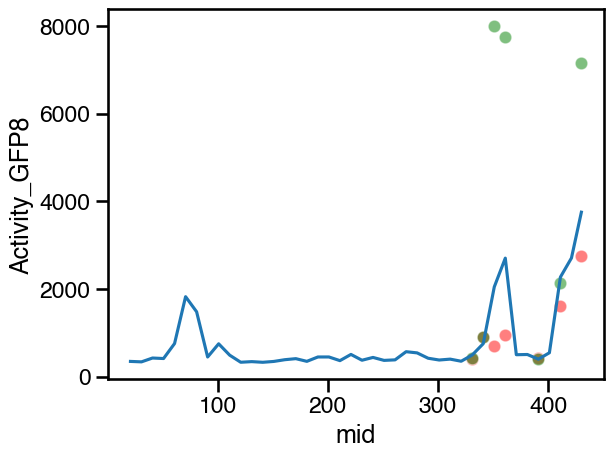

In [303]:
sns.lineplot(data = basic_sort2_vs_sort3, x = "mid", y = "Activity_GFP8")
sns.scatterplot(data = pd.merge(PSv_conf2fA_STYA, sort2_PSv_conf2fA_STYA), x = "mid", y = "Activity_GFP8", color = "red", alpha = 0.5)
sns.scatterplot(data = pd.merge(PSv_conf2fD, sort2_PSv_conf2fD), x = "mid", y = "Activity_GFP8", color = "green", alpha = 0.5)

In [306]:
sort2_js_sort3_overlap = pd.merge(js_activities, sort2, on = "AAseq", suffixes = ("_s2", "_s3"))
sort2_js_sort3_overlap

,ArrayDNA,Activity_GFP8_s2,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std,Activity_GFP4,Activity_GFP8_s3
0,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,636.156202,614.613867,944.856101,6448.0,115.0,EDPTWFDSGSQFILNSQQLVEALSLCDDAAGSQDREENTN,779.734984,233.516523,183.082210,636.156202
1,GAAGCTTTGTCTTTGTGTGATGATTTGTTGGGTGATCAAGATAGAG...,602.696194,541.936177,992.565641,10829.0,1680.0,EALSLCDDLLGDQDREENDNDGDLKDKQPCIADYAHLGPE,767.250909,318.643150,165.429679,602.696194
2,GATTTGGCTGAAGATGATGAAGTTATGTGTATGGAAGATGAAGTTC...,381.502348,390.255889,390.758385,91062.0,892.0,DLAEDDEVMCMEDEVQSIQPNHERPDDGPELEHGLENGAK,390.507137,0.355319,139.428825,381.502348
3,GGTCAAAGGAAGAGAAGGAAGATTACTCCAACTTTGGTTAATGATG...,347.155741,430.848450,865.176167,13900.0,140.0,GQRKRRKITPTLVNDEPVRWHKTGRTKPVMLSGVQRGCKK,648.012309,307.116074,127.998377,347.155741
4,TCTGAATTGACTTCTACTTTGGGTATTTCTCATAGATTGCCACAAT...,437.694050,470.823534,3562.821795,10128.0,246.0,SELTSTLGISHRLPQSLTPCVKTGSLQSGGLVQSVPFEEL,2016.822664,2186.372938,141.237171,437.694050
...,...,...,...,...,...,...,...,...,...,...,...
1705,GAAGATCCAACTTGGTTTGATTCTGGTGATCAATTTATCTTGAATG...,7960.852191,5308.586517,1810.174287,4804.0,18.0,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGSQDREENTN,3559.380402,2473.751011,1462.000000,7960.852191
1706,GAAGATCCAACTTGGTTTGATTCTGGTGATCAATTTATCTTGAATG...,7960.852191,5308.586517,1810.174287,4804.0,18.0,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGSQDREENTN,3559.380402,2473.751011,1462.000000,7960.852191
1707,GAAGATCCAACTTGGTTTGATTCTGGTGATCAAGCTATTGCTAATG...,2769.615372,2264.103416,355.344665,3121.0,57.0,EDPTWFDSGDQAIANDQQLVEALSLCDDLLGDQDREENTN,1309.724041,1349.696256,1462.000000,2769.615372
1708,GAAGATCCAACTGCTGATGCTGCTATTCAACAATTGTGGAATCAAG...,5603.789064,237.000000,NaN,17.0,NaN,EDPTADAAIQQLWNQGFLFVESLSLCDDLLGAQDREENTN,237.000000,NaN,1462.000000,5603.789064


In [322]:
js_activities["Activity_S3_1"].isna().sum()

295

In [320]:
js_activities["Activity_GFP8"].isna().sum()

9197

<Figure size 5760x4320 with 0 Axes>

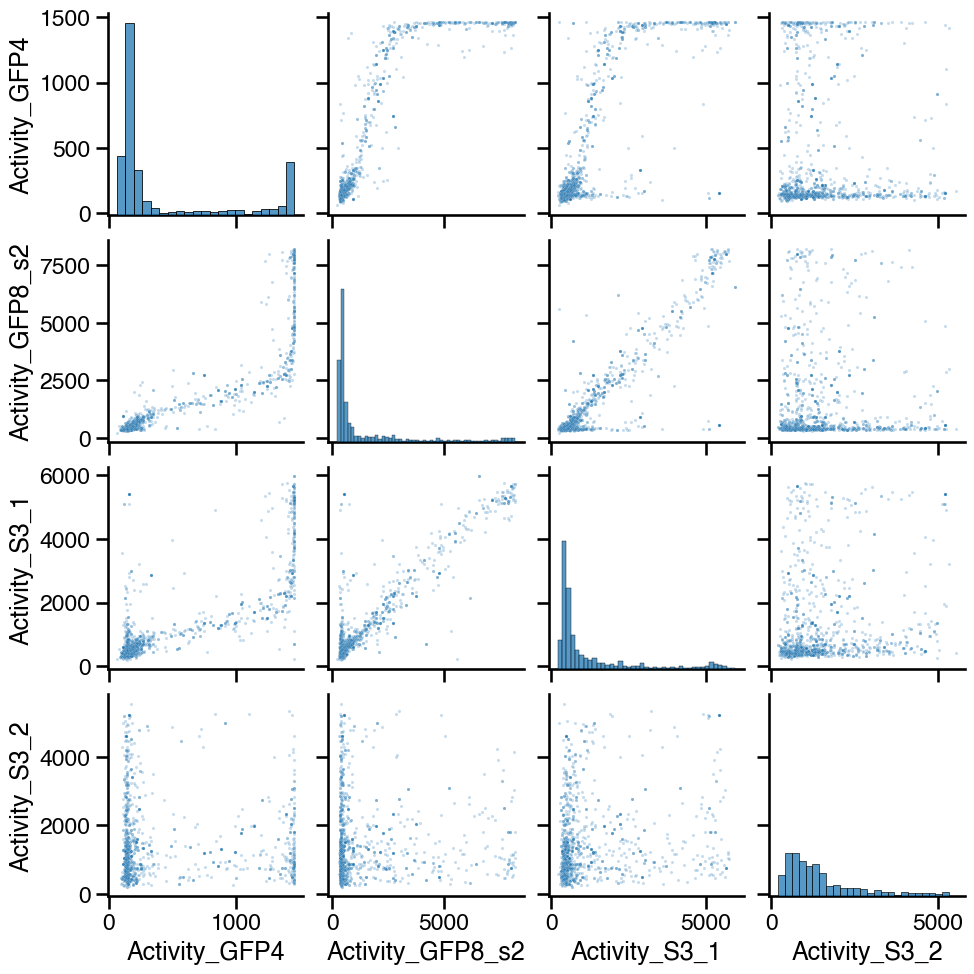

In [330]:
plt.figure(dpi = 900)
sns.pairplot(sort2_js_sort3_overlap[["Activity_GFP4", "Activity_GFP8_s2", "Activity_S3_1", "Activity_S3_2"]], plot_kws = {"s" : 5, "alpha" : 0.25})

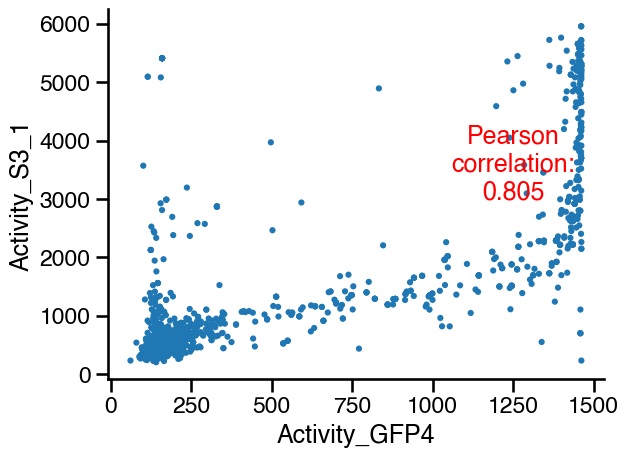

In [323]:
plot_correl("Activity_GFP4", "Activity_S3_1", sort2_js_sort3_overlap, alpha =1 , s = 20, text_x = 1250, text_y = 3000)

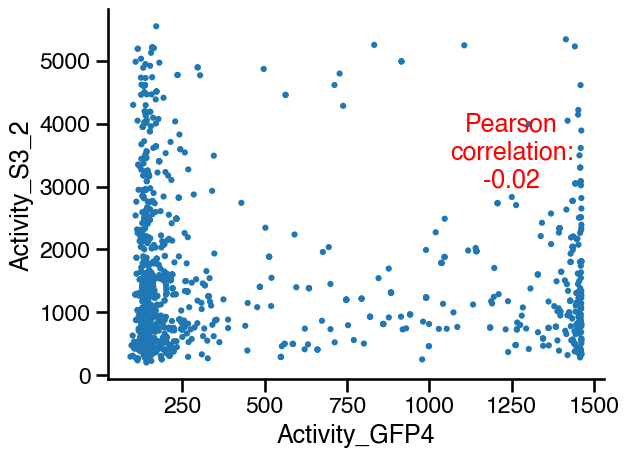

In [324]:
plot_correl("Activity_GFP4", "Activity_S3_2", sort2_js_sort3_overlap, alpha =1 , s = 20, text_x = 1250, text_y = 3000)

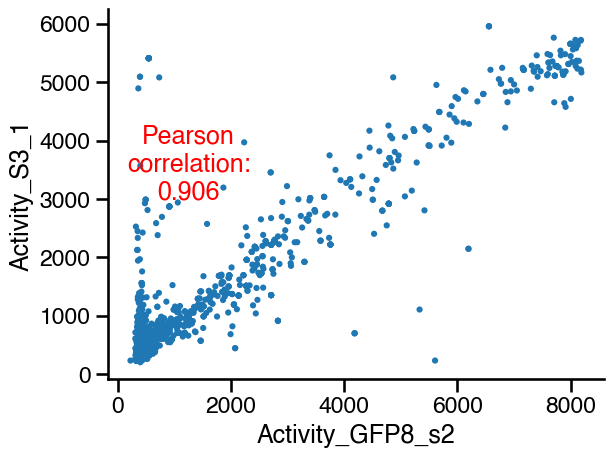

In [325]:
plot_correl("Activity_GFP8_s2", "Activity_S3_1", sort2_js_sort3_overlap, alpha =1 , s = 20, text_x = 1250, text_y = 3000)

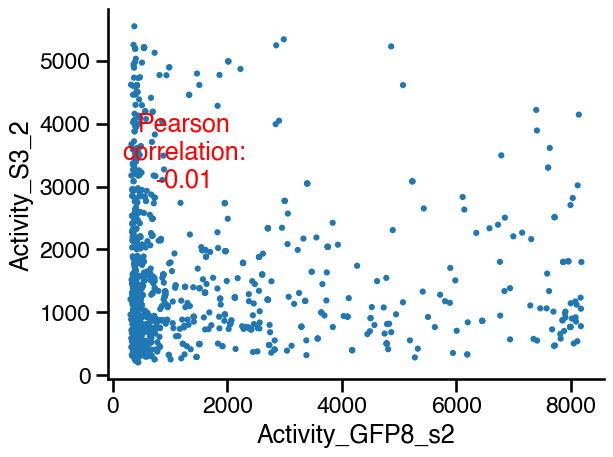

In [326]:
plot_correl("Activity_GFP8_s2", "Activity_S3_2", sort2_js_sort3_overlap, alpha =1 , s = 20, text_x = 1250, text_y = 3000)

In [344]:
library["ProteinSeq"] = library["ProteinSeq"].astype(str).str.strip()
library

,ProteinSeq,Description,Other
0,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0
1,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,AD1_Aro2A_0,GAL4_AD1_Aro2A_0
2,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,AD1_L2A_0,GAL4_AD1_L2A_0
3,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0
4,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_WLF_A_0,GCN4_CAAD40_WLF_A_0
...,...,...,...
23344,EALSLCDDLDDEQDREENTNSGSLKDKQPCIADYAHLGPE,37_PSvsCHA_hyperE_DD_all,/
23345,DEQDREEDTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,38_PSvsCHA_hyperE_DD_all,/
23346,IADYAHLGPEDFKRDLEECQKIVLDPSNDEDDEPPEDRDE,40_PSvsCHA_hyperE_DD_all,Pro subst
23347,DFKRDLEECQKIVLDPSNDEDDEPPEFRDEQDEFDEQDDF,41_PSvsCHA_hyperE_DD_all,Pro subst


In [345]:
js_activities

,ArrayDNA,Activity_GFP8,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,636.156202,614.613867,944.856101,6448.0,115.0,EDPTWFDSGSQFILNSQQLVEALSLCDDAAGSQDREENTN,779.734984,233.516523
1,GAAGCTTTGTCTTTGTGTGATGATTTGTTGGGTGATCAAGATAGAG...,602.696194,541.936177,992.565641,10829.0,1680.0,EALSLCDDLLGDQDREENDNDGDLKDKQPCIADYAHLGPE,767.250909,318.643150
2,GATTTGGCTGAAGATGATGAAGTTATGTGTATGGAAGATGAAGTTC...,381.502348,390.255889,390.758385,91062.0,892.0,DLAEDDEVMCMEDEVQSIQPNHERPDDGPELEHGLENGAK,390.507137,0.355319
3,GGTCAAAGGAAGAGAAGGAAGATTACTCCAACTTTGGTTAATGATG...,347.155741,430.848450,865.176167,13900.0,140.0,GQRKRRKITPTLVNDEPVRWHKTGRTKPVMLSGVQRGCKK,648.012309,307.116074
4,TCTGAATTGACTTCTACTTTGGGTATTTCTCATAGATTGCCACAAT...,437.694050,470.823534,3562.821795,10128.0,246.0,SELTSTLGISHRLPQSLTPCVKTGSLQSGGLVQSVPFEEL,2016.822664,2186.372938
...,...,...,...,...,...,...,...,...,...
10304,TTGGAACATGGTTTGGAAAGAGGTGCTAAAGAAATGTTGGATGATA...,NaN,NaN,3570.989020,NaN,11.0,LEHGLERGAKEMLDDKEEREKDRDRERRGEEDPTWFDSGS,3570.989020,NaN
10305,GAAGATGAAGAATGGTTTGATGAAGAAGCTCAATTTATCTTGAATG...,NaN,NaN,3330.752810,NaN,13.0,EDEEWFDEEAQFILNAQQLVEALSLCDDLLGAQDREEEEN,3330.752810,NaN
10306,ACTCAATCTCAATCTTCTAGATCTAGAAATATTCCACCACCACAAG...,NaN,NaN,5347.917675,NaN,11.0,TQSQSSRSRNIPPPQANSSRAREIGNGSKTTMVDEIPMSV,5347.917675,NaN
10307,GACTTTAAGAGAGATTTGGAAGAATGTCAGAAGATTGTCTTGGATC...,NaN,NaN,5545.836977,NaN,21.0,DFKRDLEECQKIVLDPSNIELRPDPETFLSQLEFGSQDSF,5545.836977,NaN


In [351]:
pd.merge(library, js_activities, left_on = "ProteinSeq", right_on = "AAseq")

,ProteinSeq,Description,Other,ArrayDNA,Activity_GFP8,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0,TCTACTATTCCATTGGACTTTATGCCAAGAGATGCTTTGCATGGAT...,5071.236824,4062.367477,4613.647910,3831.0,904.0,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,4338.007693,389.814133
1,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,AD1_Aro2A_0,GAL4_AD1_Aro2A_0,TCTACTATTCCATTGGATGCTATGCCAAGAGATGCTTTGCATGGTG...,NaN,399.443059,458.925937,857.0,995.0,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,429.184498,42.060747
2,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,AD1_L2A_0,GAL4_AD1_L2A_0,TCTACTATTCCAGCTGACTTTATGCCAAGAGATGCTGCTCATGGAT...,NaN,2659.623882,286.758023,25.0,11.0,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,1473.190952,1677.869540
3,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0,TCTACTGATTCTACTCCAATGTTTGAATATGAGAATTTGGAAGATA...,3188.980214,2994.983206,NaN,4438.0,NaN,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,2994.983206,NaN
4,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_MFYL_A_0,GCN4_CAAD40_MFYL_A_0,TCTACTGATTCTACTCCAGCTGCTGAAGCTGAGAATGCTGAAGATA...,NaN,2389.259079,1563.240048,86.0,74.0,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,1976.249564,584.083658
...,...,...,...,...,...,...,...,...,...,...,...,...
7946,QFILDDQQLVEALSLCDDLLDDQDREENTNSGSLKDKQPC,36_PSvsCHA_hyperD_D_all,/,CAATTTATCTTGGATGATCAACAATTGGTTGAAGCTTTGTCTTTGT...,NaN,2237.195101,2382.569766,31722.0,26455.0,QFILDDQQLVEALSLCDDLLDDQDREENTNSGSLKDKQPC,2309.882433,102.795412
7947,EDPTWFDSGEQFILDEQDLVEALSLCDDLLGEQDREENTN,35_PSvsCHA_hyperE_DD_one,/,GAAGATCCAACTTGGTTTGATTCTGGTGAACAATTTATCTTGGATG...,NaN,5657.450092,5280.832615,3980.0,6995.0,EDPTWFDSGEQFILDEQDLVEALSLCDDLLGEQDREENTN,5469.141354,266.308772
7948,KDRDNENQGEEDPTWFDSEEQFILEEQQLVEALSLCDDLL,34_PSvsCHA_hyperE_E_all,/,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTTGGT...,NaN,907.958498,682.479771,45.0,51.0,KDRDNENQGEEDPTWFDSEEQFILEEQQLVEALSLCDDLL,795.219134,159.437537
7949,EDPTWFDSEEQFILEEQQLVEALSLCDDLLEEQDREENTN,35_PSvsCHA_hyperE_E_all,/,GAAGATCCAACTTGGTTTGATTCTGAAGAACAATTTATCTTGGAAG...,NaN,436.060758,370.813194,37.0,55.0,EDPTWFDSEEQFILEEQQLVEALSLCDDLLEEQDREENTN,403.436976,46.136995


In [365]:
js_activities[js_activities["AAseq"].isin(library["ProteinSeq"])].dropna(subset = [ "Activity_S3_1"])

,ArrayDNA,Activity_GFP8,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,636.156202,614.613867,944.856101,6448.0,115.0,EDPTWFDSGSQFILNSQQLVEALSLCDDAAGSQDREENTN,779.734984,233.516523
1,GAAGCTTTGTCTTTGTGTGATGATTTGTTGGGTGATCAAGATAGAG...,602.696194,541.936177,992.565641,10829.0,1680.0,EALSLCDDLLGDQDREENDNDGDLKDKQPCIADYAHLGPE,767.250909,318.643150
2,GATTTGGCTGAAGATGATGAAGTTATGTGTATGGAAGATGAAGTTC...,381.502348,390.255889,390.758385,91062.0,892.0,DLAEDDEVMCMEDEVQSIQPNHERPDDGPELEHGLENGAK,390.507137,0.355319
3,GGTCAAAGGAAGAGAAGGAAGATTACTCCAACTTTGGTTAATGATG...,347.155741,430.848450,865.176167,13900.0,140.0,GQRKRRKITPTLVNDEPVRWHKTGRTKPVMLSGVQRGCKK,648.012309,307.116074
4,TCTGAATTGACTTCTACTTTGGGTATTTCTCATAGATTGCCACAAT...,437.694050,470.823534,3562.821795,10128.0,246.0,SELTSTLGISHRLPQSLTPCVKTGSLQSGGLVQSVPFEEL,2016.822664,2186.372938
...,...,...,...,...,...,...,...,...,...
10008,GATAAGATTGAACAAGACTTTCCAGAATCTTCTGGTGCTTTGATTG...,NaN,4757.225440,4564.979168,15.0,14.0,DKIEQDFPESSGALIAKVDPVTPKSATPEHPLTERRNSDF,4661.102304,135.938643
10009,GGTGCTCAAGATAGAGAAGAGAATGAGAATGAAGGTGAATTGAAAG...,NaN,3157.226856,3978.344715,13.0,11.0,GAQDREENENEGELKDKQPCIADYAHLGPEDFKRDLEECQ,3567.785786,580.618006
10012,GAAGATCCAGAATGGTTTGATGAAGGTGCTCAATTTATCTTGAATG...,NaN,5581.445157,5614.520424,418.0,1066.0,EDPEWFDEGAQFILNEQQLVEALSLCDDLLGEQDREENEN,5597.982791,23.387746
10013,GATGAAGCTATTCCAACTGTTAATCAAGATGATGGTATTTGTGCTA...,NaN,5830.962190,4533.479191,43.0,76.0,DEAIPTVNQDDGICATHPKNAPGVKSDGTVSHAAHKAIKA,5182.220691,917.459027


In [353]:
library[library["ProteinSeq"].str.contains("EALSLCDDLLGDQDREENDNDGDLKDKQPCIADYAHLGPE")]

,ProteinSeq,Description,Other
13550,EALSLCDDLLGDQDREENDNDGDLKDKQPCIADYAHLGPE,37_PSv_pred2D,/


In [366]:
js_activities[~js_activities["AAseq"].isin(library["ProteinSeq"])].dropna(subset = [ "Activity_S3_1"])

,ArrayDNA,Activity_GFP8,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
5,GAAATGGCTGATGATAAAGAAGAACAAGAGAAAGATAGAGATAATG...,440.094608,380.260708,876.969813,8663.0,163.0,EMADDKEEQEKDRDNENQGEEDPTWADSGDQFIANSQQLV,628.615261,351.226376
9,GATGCTAAGAGAGATGCTGAAGAATGTCAGAAGATTGTTGCTGATC...,338.856762,740.411996,2401.857236,961.0,19.0,DAKRDAEECQKIVADPSNIEADTPPEARASQAEAGDQDSA,1571.134616,1174.819196
10,GATGCTAAGAGAGATGCTGAAGAATGTCAGAAGATTGTTGCTGATC...,368.839504,962.205368,NaN,1051.0,NaN,DAKRDAEECQKIVADPSNIEADDPPEARASQAEAGSQDSA,962.205368,NaN
11,CAGAAGATTGTTGCTGATCCATCTAATATTGAATTGGATGCTCCAC...,374.674529,375.061643,1520.835984,8882.0,27.0,QKIVADPSNIELDAPPEARLSQAEFGSQDSALAAGTGKTD,947.948813,810.184806
13,AAGAAGAGGAAGAATAAGAATCAAGGTAAGAAGAAACCAACTTGGT...,437.229343,570.650711,2973.287121,75788.0,2565.0,KKRKNKNQGKKKPTWFKSGAQFILNAQQLVKAASACKKLL,1771.968916,1698.920498
...,...,...,...,...,...,...,...,...,...
10001,AAAGATAGAGATAATGAGAATCCAACTGAATGGGAAGATGGATTTC...,NaN,5622.493202,5010.381759,43.0,56.0,KDRDNENPTEWEDGFQDSGSQFILNSQQLVEALSLCDDLL,5316.437481,432.828152
10005,GAAATGTTGGATGATAAAGAAGAACAAGAGAAAGATAGAGATAATG...,NaN,3497.039476,3752.617849,11.0,39.0,EMLDDKEEQEKDRDNENQFWEPSDEDTGGSQFILNSQQLV,3624.828663,180.721200
10010,CAGAAGATTGTCTTGGATCCATCTTTGGATAATATTACTGAACCAC...,NaN,5789.492023,5486.658567,93.0,162.0,QKIVLDPSLDNITEPPEFRLSQLEFGSQDSFLAWGTGKTD,5638.075295,214.135591
10011,GAAATGTTGGATGATAAAGAAGAACAAGAGAAAGATAGAGATAATG...,NaN,5854.336897,4011.273749,15.0,26.0,EMLDDKEEQEKDRDNENQGEEDWTPFDSGSQFILNSQQLV,4932.805323,1303.242450


In [355]:
library[library["ProteinSeq"] == "EMADDKEEQEKDRDNENQGEEDPTWADSGDQFIANSQQLV"]

,ProteinSeq,Description,Other


In [358]:
library[library["ProteinSeq"].str.contains("EMADDKEEQEKDRDNENQGEEDPTWADSGDQFIANSQQLV")]

,ProteinSeq,Description,Other


In [359]:
library

,ProteinSeq,Description,Other
0,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0
1,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,AD1_Aro2A_0,GAL4_AD1_Aro2A_0
2,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,AD1_L2A_0,GAL4_AD1_L2A_0
3,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0
4,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_WLF_A_0,GCN4_CAAD40_WLF_A_0
...,...,...,...
23344,EALSLCDDLDDEQDREENTNSGSLKDKQPCIADYAHLGPE,37_PSvsCHA_hyperE_DD_all,/
23345,DEQDREEDTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,38_PSvsCHA_hyperE_DD_all,/
23346,IADYAHLGPEDFKRDLEECQKIVLDPSNDEDDEPPEDRDE,40_PSvsCHA_hyperE_DD_all,Pro subst
23347,DFKRDLEECQKIVLDPSNDEDDEPPEFRDEQDEFDEQDDF,41_PSvsCHA_hyperE_DD_all,Pro subst


In [367]:
pd.merge(library, ec_activities, left_on = "ProteinSeq", right_on = "AAseq")

,ProteinSeq,Description,Other,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0,TCTACTATTCCATTGGACTTTATGCCAAGAGATGCTTTGCATGGAT...,4402.327299,4519.618742,8637.0,8314.0,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,4460.973020,82.937575
1,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,AD1_Aro2A_0,GAL4_AD1_Aro2A_0,TCTACTATTCCATTGGATGCTATGCCAAGAGATGCTTTGCATGGTG...,4280.237709,4195.273469,34783.0,47572.0,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,4237.755589,60.078790
2,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,AD1_L2A_0,GAL4_AD1_L2A_0,TCTACTATTCCAGCTGACTTTATGCCAAGAGATGCTGCTCATGGAT...,1520.171293,564.292349,7540.0,3552.0,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,1042.231821,675.908483
3,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0,TCTACTGATTCTACTCCAATGTTTGAATATGAGAATTTGGAAGATA...,975.339096,696.700377,23.0,25.0,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,836.019736,197.027327
4,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_WLF_A_0,GCN4_CAAD40_WLF_A_0,TCTACTGATTCTACTCCAATGTTTGAATATGAGAATTTGGAAGATA...,868.819169,828.569662,77.0,77.0,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,848.694415,28.460699
...,...,...,...,...,...,...,...,...,...,...,...
8663,EDPTWFDSGEQFILDEQDLVEALSLCDDLLGEQDREENTN,35_PSvsCHA_hyperE_DD_one,/,GAAGATCCAACTTGGTTTGATTCTGGTGAACAATTTATCTTGGATG...,5724.489627,5260.356648,65706.0,84191.0,EDPTWFDSGEQFILDEQDLVEALSLCDDLLGEQDREENTN,5492.423137,328.191577
8664,EMLDDKEEQEKDRDNENQGEEDPTWFDSEEQFILEEQQLV,33_PSvsCHA_hyperE_E_all,/,GAAATGTTGGATGATAAAGAAGAACAAGAGAAAGATAGAGATAATG...,1230.436990,458.577890,26.0,30.0,EMLDDKEEQEKDRDNENQGEEDPTWFDSEEQFILEEQQLV,844.507440,545.786804
8665,KDRDNENQGEEDPTWFDSEEQFILEEQQLVEALSLCDDLL,34_PSvsCHA_hyperE_E_all,/,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTTGGT...,1343.701698,839.660967,245.0,241.0,KDRDNENQGEEDPTWFDSEEQFILEEQQLVEALSLCDDLL,1091.681332,356.410619
8666,EDPTWFDSEEQFILEEQQLVEALSLCDDLLEEQDREENTN,35_PSvsCHA_hyperE_E_all,/,GAAGATCCAACTTGGTTTGATTCTGAAGAACAATTTATCTTGGAAG...,1792.208786,1464.405213,80.0,51.0,EDPTWFDSEEQFILEEQQLVEALSLCDDLLEEQDREENTN,1628.306999,231.792130


In [368]:
ec_activities[ec_activities["AAseq"].isin(library["ProteinSeq"])].dropna(subset = [ "Activity_S3_1"])

,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1079.074274,925.703811,610.0,643.0,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,1002.389042,108.449295
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,1371.861742,1170.193129,68.0,38.0,KQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRM,1271.027436,142.601244
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.663233,267.611412,5090.0,7330.0,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,275.637323,11.350351
5,AAACAACAACCATGCTTTGGTGATTATGCTCATTTGGGTGGTACTG...,1508.490533,1865.122581,163.0,209.0,KQQPCFGDYAHLGGTDDFKRDLEDCQKLVLDPCNIDLDTP,1686.806557,252.176940
13,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,1294.164331,1269.442354,26353.0,24153.0,KQDLEKCHELGLSDADFRLSQIEFSQDSCTAAWAGGNMLD,1281.803343,17.481077
...,...,...,...,...,...,...,...,...
11256,TTTGATCCATCTGATCCAGAAATTATTTGGCATTTGTTGGCTAAGA...,1865.912984,1733.697343,70.0,50.0,FDPSDPEIIWHLLAKTGSLGLTPHPFIDEFIPTVDQDDGI,1799.805163,93.490576
11264,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,2314.792506,2111.813429,124.0,121.0,FDSPDVAESFETSPLFANADADLAGQDAWFSLFPSISGGE,2213.302968,143.527882
11266,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1673.484641,1569.322449,816.0,769.0,FAAGARKRRKIHDDDFGDVRWHKAGRAKPVVLDGVQRGCK,1621.403545,73.653793
11267,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1780.391373,2360.015854,75.0,73.0,FVKDSLQDIGKYFEIDSTLDELEQVESGEGNDDLPDEEER,2070.203613,409.856401


In [369]:
ec_activities[~ec_activities["AAseq"].isin(library["ProteinSeq"])].dropna(subset = [ "Activity_S3_1"])

,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1394.076068,1424.548173,44354.0,36001.0,KQRDNEDNGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1409.312120,21.547032
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,4076.691936,3163.539743,172.0,137.0,KQIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,3620.115839,645.696108
6,AAACAAGAATTGATGGAAGAAGATGATGAGAAAGATAGAGATAATG...,1884.539399,1243.306954,99.0,106.0,KQELMEEDDEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1563.923176,453.419810
7,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,3210.295643,3818.736164,267072.0,224489.0,KQDLEKCHELGLSDADFRLDQIEFDQDSCTAAWAGGNMLD,3514.515903,430.232418
8,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,1992.235770,1943.421497,154.0,205.0,KQDLEKCHELGLSDADFRLDQIEFSQDSCTAAWAGGNMLD,1967.828634,34.516903
...,...,...,...,...,...,...,...,...
11260,TTTGATGCTCCAGATGTTGCTGAATCATTTGAAACTGCTCCATTGT...,929.890218,759.823346,306.0,309.0,FDAPDVAESFETAPLFANADADLAGQDAWFSLFPSISGGE,844.856782,120.255439
11261,TTTGATGCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,522.036933,1246.657845,1746.0,174.0,FDAPDVAESFETSPLFANADADLAGQDAWFSLFPSISGGE,884.347389,512.384361
11262,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTGATCCATTGT...,1300.081021,1332.158645,64052.0,70387.0,FDSPDVAESFETDPLFANADADLAGQDAWFSLFPSISGGE,1316.119833,22.682306
11263,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTGCTCCATTGT...,593.646208,2901.303690,27214.0,581.0,FDSPDVAESFETAPLFANADADLAGQDAWFSLFPSISGGE,1747.474949,1631.760254
